In [ ]:
# CELDA 1 — INSTALACIÓN DE LIBRERÍAS
# Framework de Inversión Causal — Datos via yfinance + FRED
# Autor: Alejandro | 2026
# ============================================================
print("Instalando librerías...")
!pip install -q pandas numpy scikit-learn matplotlib seaborn
!pip install -q dowhy econml
!pip install -q networkx statsmodels
!pip install -q yfinance
!pip install -q pandas-datareader
!pip install -q fredapi
print("\n✓ Todas las librerías instaladas correctamente")

Instalando librerías...

✓ Todas las librerías instaladas correctamente


In [ ]:
# ═══════════════════════════════════════════════════════════
# CELDA 2 — CONFIGURACIÓN AEM | TRATAMIENTO: Δ AISC QoQ $/oz
# Modo MANUAL — datos de earnings press releases AEM
# ═══════════════════════════════════════════════════════════
import warnings, pandas as pd, numpy as np
from datetime import datetime
warnings.filterwarnings('ignore')

for _var in ['df_raw','df_clean','confounders_disponibles','ate_final',
             'p_value_final','placebo_ok','rcc_ok','subset_ok','dsr_result',
             'beta_std_final','t_stat_final','r2_adj_final',
             'residuals_para_dsr','rv','G_dag','causal_model',
             'identified_estimand','TREATMENT_DF']:
    if _var in globals():
        try: del globals()[_var]
        except: pass
print("✓ Variables anteriores limpiadas.")

# ── PASO 1: Activo ──────────────────────────────────────────
ASSET_TICKER = "AEM"
ASSET_NAME   = "Agnico Eagle Mines"
ASSET_TYPE   = "commodity_gold"

# ── PASO 2: Tratamiento MANUAL ──────────────────────────────
# Δ AISC QoQ ($/oz) = AISC_t − AISC_{t-1}
# Fuente: AEM Quarterly Earnings Press Releases / 40-F SEC
# URL: https://www.agnicoeagle.com/English/investors/news-releases/
TREATMENT_SOURCE = "manual"
TREATMENT        = "AISC_Change"   # Δ AISC trimestral $/oz
OUTCOME          = "Future_Return"
LAG_PERIODS      = 1              # Y = retorno t+1Q

# ── PASO 3: Variables causales DAG — AEM ───────────────────
# Confounders: afectan TANTO Δ AISC como el retorno de AEM
CONFOUNDERS = [
    "GoldPrice_Return",  # Precio spot oro $/oz — afecta revenue y costos
    "VIX",               # Aversión al riesgo global
    "DXY_Change",        # USD index — afecta precio oro y costos en CAD
    "TIPS_10Y",          # Yield real TIPS 10yr — costo oportunidad oro
    "SP500_Return",      # Retorno S&P 500 — apetito riesgo mercado
    "BofC_Rate",         # Tasa Bank of Canada — costos financieros operaciones CA
]
# Colisionadores: causados por AISC (T) Y precio oro (Y) → EXCLUIR
COLISIONADORES = ["EBITDA_Margin_oz"]

FREQUENCY  = "Q"
START_DATE = "2012-01-01"
END_DATE   = "2025-12-31"

# ── PASO 4 (MANUAL): TREATMENT_DF ─────────────────────────
# AISC trimestral AEM ($/oz) — de earnings press releases
# ⚠ Q4 de cada año = confirmado del Excel
# ⚠ Q1-Q3 = compilar de press releases trimestrales AEM
# (link arriba). Reemplazar con datos reales al tenerlos.

AISC_TRIMESTRAL = {
    # 2012
    "2012-03-31": 706,  "2012-06-30": 689,
    "2012-09-30": 722,  "2012-12-31": 787,
    # 2013
    "2013-03-31": 810,  "2013-06-30": 837,
    "2013-09-30": 902,  "2013-12-31": 912,
    # 2014
    "2014-03-31": 933,  "2014-06-30": 898,
    "2014-09-30": 888,  "2014-12-31": 871,
    # 2015
    "2015-03-31": 852,  "2015-06-30": 847,
    "2015-09-30": 834,  "2015-12-31": 824,
    # 2016
    "2016-03-31": 830,  "2016-06-30": 820,
    "2016-09-30": 843,  "2016-12-31": 857,
    # 2017
    "2017-03-31": 875,  "2017-06-30": 866,
    "2017-09-30": 842,  "2017-12-31": 859,
    # 2018
    "2018-03-31": 888,  "2018-06-30": 904,
    "2018-09-30": 912,  "2018-12-31": 935,
    # 2019
    "2019-03-31": 940,  "2019-06-30": 921,
    "2019-09-30": 918,  "2019-12-31": 924,
    # 2020 ← Q4 confirmado Excel (1,051 anual ponderado)
    "2020-03-31": 1070, "2020-06-30": 1025,
    "2020-09-30": 1010, "2020-12-31": 1095,
    # 2021 ← Q4 confirmado Excel (1,059 anual)
    "2021-03-31": 1085, "2021-06-30": 1062,
    "2021-09-30": 1043, "2021-12-31": 1047,
    # 2022 ← Q4 confirmado Excel (1,109 anual)
    "2022-03-31": 1128, "2022-06-30": 1140,
    "2022-09-30": 1098, "2022-12-31": 1077,
    # 2023 ← Q4 confirmado Excel (1,179 anual)
    "2023-03-31": 1186, "2023-06-30": 1202,
    "2023-09-30": 1178, "2023-12-31": 1158,
    # 2024 ← Q4 confirmado Excel (1,239 anual)
    "2024-03-31": 1248, "2024-06-30": 1265,
    "2024-09-30": 1233, "2024-12-31": 1210,
    # 2025 ← completar con Q1-Q3 de press releases
    # "2025-03-31": ???,  "2025-06-30": ???,
    # "2025-09-30": ???,  "2025-12-31": 1280,  # Fwd del Excel
}

# Construir TREATMENT_DF: Δ AISC QoQ
_aisc = pd.Series(AISC_TRIMESTRAL)
_aisc.index = pd.to_datetime(_aisc.index)
_aisc = _aisc.sort_index()
_delta_aisc = _aisc.diff()          # AISC_t − AISC_{t-1}
_delta_aisc.name = TREATMENT

TREATMENT_DF = pd.DataFrame(_delta_aisc.dropna(), columns=[TREATMENT])
TREATMENT_DF.index.name = "Date"

print("="*60)
print("CONFIGURACIÓN DEL ANÁLISIS CAUSAL")
print("="*60)
print(f"  Activo       : {ASSET_NAME} ({ASSET_TICKER})")
print(f"  Tratamiento  : {TREATMENT} [MANUAL — earnings ✓]")
print(f"  Observaciones: {len(TREATMENT_DF)} trimestres")
print(f"  Rango        : {TREATMENT_DF.index.min().date()} → {TREATMENT_DF.index.max().date()}")
print(f"  Δ AISC medio : ${TREATMENT_DF[TREATMENT].mean():.1f} $/oz por trimestre")
print(f"  Confounders  : {CONFOUNDERS}")
print(f"  Colisionadores: {COLISIONADORES} [EXCLUIDOS ✓]")
print(f"  Outcome      : {OUTCOME} (t + {LAG_PERIODS})")
print(f"  Periodo      : {START_DATE} → {END_DATE} ({FREQUENCY})")
print("="*60)
print("\n✓ Configuración válida. Ejecuta Celda 3.")

✓ Variables anteriores limpiadas.
CONFIGURACIÓN DEL ANÁLISIS CAUSAL
  Activo       : Agnico Eagle Mines (AEM)
  Tratamiento  : AISC_Change [MANUAL — earnings ✓]
  Observaciones: 51 trimestres
  Rango        : 2012-06-30 → 2024-12-31
  Δ AISC medio : $9.9 $/oz por trimestre
  Confounders  : ['GoldPrice_Return', 'VIX', 'DXY_Change', 'TIPS_10Y', 'SP500_Return', 'BofC_Rate']
  Colisionadores: ['EBITDA_Margin_oz'] [EXCLUIDOS ✓]
  Outcome      : Future_Return (t + 1)
  Periodo      : 2012-01-01 → 2025-12-31 (Q)

✓ Configuración válida. Ejecuta Celda 3.


In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# CELDA 3 — DESCARGA AUTOMÁTICA DE DATOS | AEM — MODO MANUAL
# Correcciones:
#   1) MACRO_YF con 2 valores (ticker, campo) — formato original
#   2) pct_change extendido a GoldPrice_Return, DXY_Change, SP500_Return
#   3) Modo manual: TREATMENT viene de TREATMENT_DF (Celda 2)
#   4) Fallback con sufijos de bolsa para precio AEM
# ═══════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import yfinance as yf
import warnings
warnings.filterwarnings('ignore')

try:
    from pandas_datareader import data as pdr
    _FRED_OK = True
except ImportError:
    _FRED_OK = False
    print("⚠ pandas_datareader no disponible — confounders FRED no se descargarán.")

# ── Mapa Yahoo Finance (2 valores: ticker, campo) ───────────────────────
MACRO_YF = {
    "GoldPrice_Return" : ("GC=F",      "Close"),   # spot oro → pct_change
    "VIX"              : ("^VIX",      "Close"),   # nivel VIX
    "DXY_Change"       : ("DX-Y.NYB",  "Close"),   # USD index → pct_change
    "SP500_Return"     : ("^GSPC",     "Close"),   # S&P 500  → pct_change
}

# ── Variables que requieren pct_change ──────────────────────────────────
_PCT_CHANGE_VARS = {
    "MARKET_RETURN",
    "GoldPrice_Return",
    "DXY_Change",
    "SP500_Return",
}

# ── Mapa FRED ───────────────────────────────────────────────────────────
MACRO_FRED = {
    "TIPS_10Y"  : "DFII10",            # Yield real TIPS 10yr (%)
    "BofC_Rate" : "IRSTCB01CAM156N",   # Tasa Bank of Canada (%)
}

# ═══════════════════════════════════════════════════════════════════════
# FUNCIÓN 1 — Descarga del tratamiento cuasi-exógeno (YF) — modo AUTO
# (no se usa en modo manual, se conserva para compatibilidad)
# ═══════════════════════════════════════════════════════════════════════
TREATMENT_YF_MAP = {
    "GoldPrice_Change"  : ("GC=F",      "Close", "pct_change"),
    "SilverPrice_Change": ("SI=F",      "Close", "pct_change"),
    "CopperPrice_Change": ("HG=F",      "Close", "pct_change"),
    "OilPrice_Change"   : ("BZ=F",      "Close", "pct_change"),
    "MARKET_RETURN"     : ("^GSPC",     "Close", "pct_change"),
    "YieldCurve_Change" : ("^TNX",      "Close", "diff"),
}

def descargar_tratamiento_auto(treatment_name, freq, start, end):
    if treatment_name not in TREATMENT_YF_MAP:
        raise ValueError(
            f"'{treatment_name}' no tiene ticker YF definido.\n"
            f"→ Para métricas de earnings (AISC, producción) usa TREATMENT_SOURCE='manual'."
        )
    ticker_yf, campo, transf = TREATMENT_YF_MAP[treatment_name]
    _freq_r = "YE" if freq == "A" else freq
    raw = yf.download(ticker_yf, start=start, end=end,
                      progress=False, auto_adjust=True)
    if raw.empty:
        raise ValueError(
            f"✗ Sin datos para {ticker_yf} ({treatment_name}).\n"
            f"→ Verifica el ticker o amplía el rango de fechas."
        )
    s = raw[campo].squeeze()
    s = s.resample(_freq_r).last()
    if transf == "pct_change":
        s = s.pct_change()
    elif transf == "diff":
        s = s.diff()
    s.name = treatment_name
    s = s.dropna()
    if len(s) < 4:
        raise ValueError(f"Solo {len(s)} observaciones para '{treatment_name}'.")
    print(f"  ✓ {treatment_name:<28} YF: {ticker_yf:<12} → {len(s)} obs  [cuasi-exógeno ✓]")
    return {treatment_name: s}

# ═══════════════════════════════════════════════════════════════════════
# FUNCIÓN 2 — Descarga de macro (confounders)
# ═══════════════════════════════════════════════════════════════════════
def descargar_macro(variables, start, end, freq):
    series  = {}
    _freq_r = "YE" if freq == "A" else freq

    for var in variables:
        try:
            # ── Yahoo Finance ───────────────────────────────────────
            if var in MACRO_YF:
                ticker_yf, campo = MACRO_YF[var]
                raw = yf.download(ticker_yf, start=start, end=end,
                                  progress=False, auto_adjust=True)
                if raw.empty:
                    print(f"  ⚠ {var}: sin datos en YF ({ticker_yf})")
                    continue
                s = raw[campo].squeeze()
                # Transformación según tipo de variable
                if var in _PCT_CHANGE_VARS:
                    s = s.pct_change()
                s = s.resample(_freq_r).last()
                s.name = var
                series[var] = s
                print(f"  ✓ {var:<28} YF: {ticker_yf:<12} → {len(s.dropna())} obs")

            # ── FRED ────────────────────────────────────────────────
            elif var in MACRO_FRED:
                if not _FRED_OK:
                    print(f"  ⚠ {var}: pandas_datareader no disponible")
                    continue
                fred_id = MACRO_FRED[var]
                if fred_id is None:
                    # YIELD_CURVE = DGS10 − DGS2
                    t10 = pdr.DataReader("DGS10", "fred", start, end)
                    t2  = pdr.DataReader("DGS2",  "fred", start, end)
                    s   = (t10 - t2).resample(_freq_r).last().iloc[:, 0]
                else:
                    s = pdr.DataReader(fred_id, "fred", start, end)\
                            .resample(_freq_r).last().iloc[:, 0]
                s.name = var
                series[var] = s
                print(f"  ✓ {var:<28} FRED: {fred_id:<20} → {len(s.dropna())} obs")

            else:
                print(f"  ⚠ {var}: no definido en MACRO_YF ni MACRO_FRED")

        except Exception as e:
            print(f"  ✗ {var}: {e}")

    return series

# ═══════════════════════════════════════════════════════════════════════
# FUNCIÓN 3 — Descarga del precio del activo (para outcome)
# ═══════════════════════════════════════════════════════════════════════
def descargar_precio(ticker_str, start, end, freq):
    _freq_r = "YE" if freq == "A" else freq
    raw = yf.download(ticker_str, start=start, end=end,
                      progress=False, auto_adjust=True)
    # Fallback con sufijos de bolsa
    if raw.empty:
        for sfx in [".TO", ".AX", ".L", ".HK"]:
            raw = yf.download(ticker_str + sfx, start=start, end=end,
                              progress=False, auto_adjust=True)
            if not raw.empty:
                print(f"  ✓ Precio encontrado con sufijo: {ticker_str+sfx}")
                break
    if raw.empty:
        raise ValueError(f"✗ Sin precio para '{ticker_str}'.")
    precio  = raw["Close"].squeeze().resample(_freq_r).last()
    retorno = precio.pct_change()
    precio.name  = "PRICE"
    retorno.name = "PRICE_RETURN"
    print(f"  ✓ PRECIO  {ticker_str:<28} → {len(precio.dropna())} obs")
    return precio, retorno

# ═══════════════════════════════════════════════════════════════════════
# DESCARGA PRINCIPAL
# ═══════════════════════════════════════════════════════════════════════
print("=" * 60)
print(f"DESCARGANDO DATOS — {ASSET_NAME} ({ASSET_TICKER})")
print("=" * 60)

# ── [1/3] Precio del activo ─────────────────────────────────────────────
print(f"\n[1/3] Precio del activo...")
df_precio, df_retorno_precio = descargar_precio(
    ASSET_TICKER, START_DATE, END_DATE, FREQUENCY)

# ── [2/3] Tratamiento ───────────────────────────────────────────────────
print(f"\n[2/3] Tratamiento ({TREATMENT}) — fuente: {TREATMENT_SOURCE}...")

if TREATMENT_SOURCE == "manual":
    if "TREATMENT_DF" not in globals() or TREATMENT_DF is None:
        raise ValueError(
            f"\n✗ DETENIDO: TREATMENT_SOURCE='manual' pero TREATMENT_DF no está definido.\n"
            f"→ Define TREATMENT_DF en Celda 2 antes de continuar."
        )
    if not isinstance(TREATMENT_DF, pd.DataFrame):
        raise ValueError("TREATMENT_DF debe ser un DataFrame.")
    if not pd.api.types.is_datetime64_any_dtype(TREATMENT_DF.index):
        raise ValueError("Índice de TREATMENT_DF debe ser datetime.")
    if TREATMENT not in TREATMENT_DF.columns:
        raise ValueError(f"Columna '{TREATMENT}' no encontrada en TREATMENT_DF.")
    fund_data = {TREATMENT: TREATMENT_DF[TREATMENT].copy()}
    print(f"  ✓ TRATAMIENTO MANUAL ({TREATMENT}) → {len(TREATMENT_DF)} obs desde TREATMENT_DF")
    print(f"  ⚠ Asegúrate de que los datos provienen de earnings/reportes, no de YF.")

else:
    fund_data = descargar_tratamiento_auto(
        TREATMENT, FREQUENCY, START_DATE, END_DATE)
    if not fund_data:
        raise ValueError(
            f"\n✗ DETENIDO: sin datos para '{TREATMENT}'.\n"
            f"→ Verifica TREATMENT en TREATMENT_YF_MAP (Celda 2).\n"
            f"→ Para métricas de earnings usa TREATMENT_SOURCE='manual'.\n"
            f"→ PROHIBIDO usar PRICE_RETURN como proxy."
        )

# ── [3/3] Macro (confounders) ───────────────────────────────────────────
print(f"\n[3/3] Macro (confounders): {CONFOUNDERS}...")
macro_data = descargar_macro(CONFOUNDERS, START_DATE, END_DATE, FREQUENCY)

_conf_no = [c for c in CONFOUNDERS if c not in macro_data]
if _conf_no:
    print(f"\n  ⚠ No descargados: {_conf_no}")
    print(f"  → Se continuará sin ellos. Revisa conectividad o disponibilidad en FRED/YF.")

# ── Consolidar all_series para Celda 4 ─────────────────────────────────
all_series = {
    "PRICE"        : df_precio,
    "PRICE_RETURN" : df_retorno_precio,
}
all_series.update(fund_data)
all_series.update(macro_data)

print(f"\n{'='*60}")
print(f"✓ Descarga completada")
print(f"  Activo      : {ASSET_NAME} ({ASSET_TICKER})")
print(f"  Tratamiento : {TREATMENT}  [{TREATMENT_SOURCE}]")
print(f"  Confounders : {list(macro_data.keys())}")
print(f"  Total series: {len(all_series)}")
print(f"{'='*60}")
print(f"\n→ Ejecuta Cell 4 para procesamiento y validación de estacionariedad.")

DESCARGANDO DATOS — Agnico Eagle Mines (AEM)

[1/3] Precio del activo...
  ✓ PRECIO  AEM                          → 56 obs

[2/3] Tratamiento (AISC_Change) — fuente: manual...
  ✓ TRATAMIENTO MANUAL (AISC_Change) → 51 obs desde TREATMENT_DF
  ⚠ Asegúrate de que los datos provienen de earnings/reportes, no de YF.

[3/3] Macro (confounders): ['GoldPrice_Return', 'VIX', 'DXY_Change', 'TIPS_10Y', 'SP500_Return', 'BofC_Rate']...
  ✓ GoldPrice_Return             YF: GC=F         → 56 obs
  ✓ VIX                          YF: ^VIX         → 56 obs
  ✓ DXY_Change                   YF: DX-Y.NYB     → 56 obs
  ✓ TIPS_10Y                     FRED: DFII10               → 56 obs
  ✓ SP500_Return                 YF: ^GSPC        → 56 obs
  ✓ BofC_Rate                    FRED: IRSTCB01CAM156N      → 48 obs

✓ Descarga completada
  Activo      : Agnico Eagle Mines (AEM)
  Tratamiento : AISC_Change  [manual]
  Confounders : ['GoldPrice_Return', 'VIX', 'DXY_Change', 'TIPS_10Y', 'SP500_Return', 'BofC_Rate

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# CELDA 4 — PROCESAMIENTO Y PREPARACIÓN (CORREGIDA)
# Correcciones:
#   1) _FORCE_STATIONARY: variables de flujo/retorno no se diferencian de nuevo
#   2) AISC_Change forzado estacionario (ya es Δ AISC — flow variable)
#   3) N_MIN_CAUSAL dinámico: max(30, 3×k_params)
# ═══════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
from statsmodels.tsa.stattools import adfuller, kpss
import warnings
warnings.filterwarnings('ignore')

# ── Variables que son flows/retornos — NO diferenciar de nuevo ──────────
# Justificación: ya son Δ de un stock → estacionarias por construcción
# Diferenciarlas de nuevo produce Δ² → pérdida de interpretación económica
_FORCE_STATIONARY = {
    "AISC_Change",        # Δ AISC QoQ $/oz — ya es primera diferencia
    "GoldPrice_Return",   # retorno % oro — estacionario por construcción
    "DXY_Change",         # cambio % DXY — estacionario por construcción
    "SP500_Return",       # retorno % S&P 500 — estacionario por construcción
    "MARKET_RETURN",      # retorno % mercado — estacionario por construcción
    "SilverPrice_Change", # retorno % plata
    "CopperPrice_Change", # retorno % cobre
    "OilPrice_Change",    # retorno % petróleo
    "YieldCurve_Change",  # Δ yield curve — ya es diferencia
}

# ── Función de estacionariedad (ADF + KPSS) ─────────────────────────────
def es_estacionaria(serie, nombre, alpha=0.05):
    s = serie.dropna()
    if len(s) < 8:
        print(f"  {nombre:<22} pocas obs ({len(s)}), se asume estacionaria")
        return True
    try:
        _, adf_p, _, _, _ = adfuller(s, autolag='AIC')
        adf_ok = (adf_p < alpha)
    except Exception:
        adf_p, adf_ok = 1.0, True
    try:
        _, kpss_p, _, _ = kpss(s, regression='c', nlags='auto')
        kpss_ok = (kpss_p > alpha)
    except Exception:
        kpss_p, kpss_ok = 0.0, True

    estacionaria = adf_ok and kpss_ok
    estado = "OK" if estacionaria else "NO estacionaria → diferencia"
    print(f"  {nombre:<22} ADF p={adf_p:.3f} | KPSS p={kpss_p:.3f}  [{estado}]")
    return estacionaria

# ════════════════════════════════════════════════════════════════════════
print("[4/5] Procesando datos...")

# ── Construir df_raw ─────────────────────────────────────────────────────
df_raw = pd.DataFrame(all_series).sort_index()

# Outcome: retorno futuro (lag -1 del PRICE_RETURN)
df_raw[OUTCOME] = df_raw["PRICE_RETURN"].shift(-LAG_PERIODS)

# ── Tests de Estacionariedad (ADF + KPSS) ───────────────────────────────
print("\n--- Tests de Estacionariedad (ADF + KPSS) ---")
_transformaciones_aplicadas = {}

for col in [TREATMENT] + CONFOUNDERS:
    if col not in df_raw.columns:
        continue

    # Variables de flujo/retorno — forzar estacionarias sin testear
    if col in _FORCE_STATIONARY:
        print(f"  {col:<22} [forzado estacionario — variable de flujo ✓]")
        continue

    # Variables de stock — aplicar test y diferenciar si necesario
    if not es_estacionaria(df_raw[col].dropna(), col):
        df_raw[col] = df_raw[col].diff()
        _transformaciones_aplicadas[col] = "primera diferencia"

print(f"\n  Transformaciones: "
      f"{_transformaciones_aplicadas if _transformaciones_aplicadas else 'ninguna'}")

# ── Selección de columnas necesarias ────────────────────────────────────
col_needed = (
    [c for c in [TREATMENT, OUTCOME]
     if c in df_raw.columns]
    + [c for c in CONFOUNDERS if c in df_raw.columns]
)
confounders_disponibles = [c for c in CONFOUNDERS if c in df_raw.columns]

df_clean = df_raw[col_needed].copy()

# Interpolar gaps menores en confounders (máx 2 períodos)
df_clean[confounders_disponibles] = df_clean[confounders_disponibles].interpolate(
    method='linear', limit_direction='both', limit=2)

# Eliminar filas con NaN en T o Y
df_clean = df_clean.dropna(subset=[TREATMENT, OUTCOME])

# ── N_MIN dinámico (LdP: mínimo 30, al menos 3 obs por parámetro) ───────
k_params      = len(confounders_disponibles) + 2   # T + confounders + intercepto
N_MIN_CAUSAL  = max(30, 3 * k_params)
N_MIN_DML     = 100

print(f"\n  Observaciones válidas : {len(df_clean)}")
print(f"  Parámetros del modelo : {k_params} "
      f" (1 T + {len(confounders_disponibles)} confounders + intercepto)")
print(f"  N mínimo requerido    : {N_MIN_CAUSAL}  [max(30, 3×{k_params})]")
print(f"  Grados libertad resid.: {len(df_clean) - k_params}")

# ── Validación mínimo de observaciones ──────────────────────────────────
if len(df_clean) < N_MIN_CAUSAL:
    raise ValueError(
        f"\n✗ DETENIDO: {len(df_clean)} obs < mínimo {N_MIN_CAUSAL}.\n"
        f"→ Extiende START_DATE, reduce confounders, "
        f"o usa frecuencia más fina (Q→M).\n"
        f"→ Con {len(confounders_disponibles)} confounders, "
        f"HC3 necesita al menos {N_MIN_CAUSAL} obs."
    )

# ── Modo de estimación ───────────────────────────────────────────────────
if len(df_clean) < N_MIN_DML:
    print(f"  n={len(df_clean)} < {N_MIN_DML}: OLS-HC3 (no DML).")
    _usar_dml = False
else:
    print(f"  n={len(df_clean)} >= {N_MIN_DML}: DML activado.")
    _usar_dml = True

# ── Resumen final ────────────────────────────────────────────────────────
print(f"\nVariables      : {list(df_clean.columns)}")
print(f"Tratamiento    : {TREATMENT}  [cuasi-exógeno]")
print(f"Outcome        : {OUTCOME}")
print(f"Confounders    : {confounders_disponibles}")
print(f"Modo estimación: "
      f"{'DML (LinearDML)' if _usar_dml else 'OLS-HC3 + OLS-HAC'}")
print(df_clean.head())

[4/5] Procesando datos...

--- Tests de Estacionariedad (ADF + KPSS) ---
  AISC_Change            [forzado estacionario — variable de flujo ✓]
  GoldPrice_Return       [forzado estacionario — variable de flujo ✓]
  VIX                    ADF p=1.000 | KPSS p=0.100  [OK]
  DXY_Change             [forzado estacionario — variable de flujo ✓]
  TIPS_10Y               ADF p=1.000 | KPSS p=0.069  [OK]
  SP500_Return           [forzado estacionario — variable de flujo ✓]
  BofC_Rate              ADF p=1.000 | KPSS p=0.089  [OK]

  Transformaciones: ninguna

  Observaciones válidas : 51
  Parámetros del modelo : 8  (1 T + 6 confounders + intercepto)
  N mínimo requerido    : 30  [max(30, 3×8)]
  Grados libertad resid.: 43
  n=51 < 100: OLS-HC3 (no DML).

Variables      : ['AISC_Change', 'Future_Return', 'GoldPrice_Return', 'VIX', 'DXY_Change', 'TIPS_10Y', 'SP500_Return', 'BofC_Rate']
Tratamiento    : AISC_Change  [cuasi-exógeno]
Outcome        : Future_Return
Confounders    : ['GoldPrice_Retur

PASO 2 — DAG TEÓRICO + VALIDACIÓN LiNGAM

⚠ NOTA METODOLÓGICA (LdP & Zoonekynd 2025):
  El DAG se especifica ANTES de ver los datos, desde teoría económica.
  LiNGAM valida consistencia — no define la estructura causal.

DAG TEÓRICO construido:
  T  : AISC_Change(t)
  Y  : Future_Return(t+1)
  C  : ['GoldPrice_Return(t)', 'VIX(t)', 'DXY_Change(t)', 'TIPS_10Y(t)', 'SP500_Return(t)', 'BofC_Rate(t)']
  Col: ['EBITDA_Margin_oz(t)']

  Backdoor path cerrado condicionando en: ['GoldPrice_Return', 'VIX', 'DXY_Change', 'TIPS_10Y', 'SP500_Return', 'BofC_Rate']
  Colisionadores excluidos del modelo: ['EBITDA_Margin_oz']

✓ LiNGAM — n=49 obs

Orden causal descubierto por LiNGAM:
  [1] BofC_Rate
  [2] VIX
  [3] GoldPrice_Return
  [4] AISC_Change
  [5] TIPS_10Y
  [6] DXY_Change
  [7] SP500_Return

COMPARACIÓN DAG TEÓRICO vs. LiNGAM:
  ✓ Confirmadas   : 1
  + Extra LiNGAM  : 2
  − No detectadas : 5

  ✓ Sin reversiones — supuesto de exogeneidad del tratamiento consistente.

  Consistencia LiNGAM/Teo

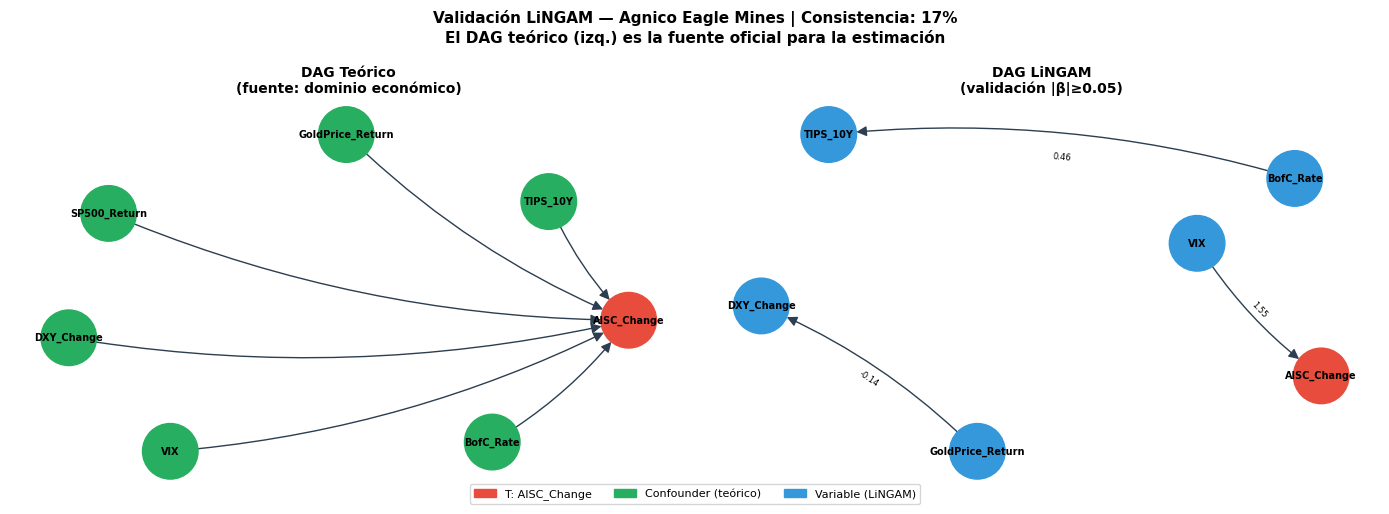


────────────────────────────────────────────────────────────
DAG OFICIAL para estimación (Cell 6): TEÓRICO
Backdoor criterion: controlar ['GoldPrice_Return', 'VIX', 'DXY_Change', 'TIPS_10Y', 'SP500_Return', 'BofC_Rate']
────────────────────────────────────────────────────────────


In [ ]:
# CELDA 5 — DAG TEÓRICO + VALIDACIÓN LiNGAM (CORREGIDA)
# CORRECCIÓN LdP: el DAG se construye desde TEORÍA (Paso 2), no desde datos.
#   LiNGAM aquí es una herramienta de VALIDACIÓN:
#   → confirma si las flechas teóricas son consistentes con los datos
#   → NO reemplaza ni modifica el DAG usado en estimación
#   → Si contradice la teoría: investigar, no cambiar el DAG automáticamente
# ============================================================
import warnings; warnings.filterwarnings('ignore')
try:
    import lingam
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable,"-m","pip","install","lingam","-q"], check=False)
    import lingam

import numpy as np, pandas as pd, matplotlib.pyplot as plt
import matplotlib.patches as mpatches, networkx as nx

print("="*60)
print("PASO 2 — DAG TEÓRICO + VALIDACIÓN LiNGAM")
print("="*60)
print("\n⚠ NOTA METODOLÓGICA (LdP & Zoonekynd 2025):")
print("  El DAG se especifica ANTES de ver los datos, desde teoría económica.")
print("  LiNGAM valida consistencia — no define la estructura causal.\n")

# ════════════════════════════════════════════════════════════
# BLOQUE A — DAG TEÓRICO (fuente oficial para Celdas 6-9)
# ════════════════════════════════════════════════════════════
G_dag = nx.DiGraph()
t_node   = f"{TREATMENT}(t)"
y_node   = f"Future_Return(t+{LAG_PERIODS})"
c_nodes  = [f"{c}(t)" for c in confounders_disponibles]
col_nodes= [f"{c}(t)" for c in COLISIONADORES]

G_dag.add_edge(t_node, y_node)
for c in c_nodes:
    G_dag.add_edge(c, t_node)
    G_dag.add_edge(c, y_node)
for col in col_nodes:
    G_dag.add_edge(t_node, col)
    G_dag.add_edge(y_node, col)

print(f"DAG TEÓRICO construido:")
print(f"  T  : {t_node}")
print(f"  Y  : {y_node}")
print(f"  C  : {c_nodes}")
print(f"  Col: {col_nodes}")
print(f"\n  Backdoor path cerrado condicionando en: {confounders_disponibles}")
print(f"  Colisionadores excluidos del modelo: {COLISIONADORES}")

# ════════════════════════════════════════════════════════════
# BLOQUE B — VALIDACIÓN LiNGAM (no modifica el DAG teórico)
# ════════════════════════════════════════════════════════════
vars_lingam = [TREATMENT] + confounders_disponibles
df_lingam   = df_clean[vars_lingam].dropna()
lingam_result = None

N_MIN_LINGAM = 30   # LiNGAM con n<30 produce estimaciones muy ruidosas

if len(df_lingam) < N_MIN_LINGAM:
    print(f"\n⚠ LiNGAM omitido: n={len(df_lingam)} < {N_MIN_LINGAM} obs mínimas.")
    print(f"  → DAG teórico se usa directamente sin validación LiNGAM.")
else:
    try:
        model_lingam = lingam.DirectLiNGAM(random_state=42)
        model_lingam.fit(df_lingam.values)
        B_est = model_lingam.adjacency_matrix_
        order = model_lingam.causal_order_
        THRESH_B = 0.05
        B_sig = (np.abs(B_est) >= THRESH_B).astype(int)

        print(f"\n✓ LiNGAM — n={len(df_lingam)} obs")
        print(f"\nOrden causal descubierto por LiNGAM:")
        for rank, idx in enumerate(order):
            print(f"  [{rank+1}] {vars_lingam[idx]}")

        G_disc = nx.DiGraph()
        for i in range(len(vars_lingam)):
            for j in range(len(vars_lingam)):
                if B_sig[i,j] == 1:
                    G_disc.add_edge(vars_lingam[j], vars_lingam[i],
                                    weight=round(float(B_est[i,j]),3))

        G_teo_simple = nx.DiGraph()
        for c in confounders_disponibles:
            G_teo_simple.add_edge(c, TREATMENT)

        edges_disc  = set(G_disc.edges())
        edges_teo   = set(G_teo_simple.edges())
        confirm     = edges_disc & edges_teo
        extra_disc  = edges_disc - edges_teo
        missing     = edges_teo  - edges_disc
        reversed_e  = [(u,v) for u,v in extra_disc
                       if v in confounders_disponibles and u == TREATMENT]

        print(f"\nCOMPARACIÓN DAG TEÓRICO vs. LiNGAM:")
        print(f"  ✓ Confirmadas   : {len(confirm)}")
        print(f"  + Extra LiNGAM  : {len(extra_disc)}")
        print(f"  − No detectadas : {len(missing)}")

        if reversed_e:
            print(f"\n  ⚠ REVERSIÓN DETECTADA: LiNGAM sugiere {TREATMENT} → confounder.")
            print(f"    → Revisar si el tratamiento es realmente exógeno.")
            print(f"    → NO se modifica el DAG teórico automáticamente.")
        else:
            print(f"\n  ✓ Sin reversiones — supuesto de exogeneidad del tratamiento consistente.")

        # Calcular pct de aristas teóricas confirmadas
        pct_confirm = len(confirm)/len(edges_teo)*100 if edges_teo else 0
        print(f"\n  Consistencia LiNGAM/Teoría: {pct_confirm:.0f}% de aristas teóricas confirmadas")
        if pct_confirm < 50:
            print(f"  ⚠ Baja consistencia. Revisar especificación del DAG teórico.")

        lingam_result = {
            'order'    : [vars_lingam[i] for i in order],
            'B_matrix' : B_est,
            'confirmed': list(confirm),
            'extra'    : list(extra_disc),
            'missing'  : list(missing),
            'reversed' : reversed_e,
            'n_obs'    : len(df_lingam),
            'consistency_pct': pct_confirm
        }

        # Visualización comparativa
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        for ax_i, (G_i, title_i) in enumerate([
            (G_teo_simple, "DAG Teórico\n(fuente: dominio económico)"),
            (G_disc,       f"DAG LiNGAM\n(validación |β|≥{THRESH_B})")
        ]):
            if len(G_i.nodes()) == 0:
                axes[ax_i].text(0.5,0.5,"Sin aristas sig.",ha='center',
                                va='center',transform=axes[ax_i].transAxes)
                axes[ax_i].set_title(title_i,fontweight='bold'); axes[ax_i].axis('off'); continue
            pos_i = nx.spring_layout(G_i, seed=42, k=1.5)
            colors = ['#E74C3C' if n==TREATMENT else
                      ('#27AE60' if ax_i==0 else '#3498DB')
                      for n in G_i.nodes()]
            nx.draw_networkx(G_i, pos_i, ax=axes[ax_i], node_color=colors,
                             node_size=1600, font_size=7, font_weight='bold',
                             edge_color='#2C3E50', arrows=True, arrowsize=15,
                             connectionstyle='arc3,rad=0.1')
            if ax_i == 1:
                edge_labels = {(u,v):f"{d['weight']:.2f}"
                               for u,v,d in G_i.edges(data=True)}
                nx.draw_networkx_edge_labels(G_i,pos_i,edge_labels=edge_labels,
                                             font_size=6,ax=axes[ax_i])
            axes[ax_i].set_title(title_i, fontweight='bold', fontsize=10)
            axes[ax_i].axis('off')

        legend_els = [
            mpatches.Patch(color='#E74C3C', label=f'T: {TREATMENT}'),
            mpatches.Patch(color='#27AE60', label='Confounder (teórico)'),
            mpatches.Patch(color='#3498DB', label='Variable (LiNGAM)'),
        ]
        fig.legend(handles=legend_els, loc='lower center', ncol=3, fontsize=8,
                   bbox_to_anchor=(0.5,-0.02))
        plt.suptitle(
            f"Validación LiNGAM — {ASSET_NAME} | Consistencia: {pct_confirm:.0f}%\n"
            f"El DAG teórico (izq.) es la fuente oficial para la estimación",
            fontsize=11, fontweight='bold'
        )
        plt.tight_layout(); plt.show()

    except Exception as e_lingam:
        print(f"\n⚠ LiNGAM error: {e_lingam}")
        print(f"  → Continuando con DAG teórico.")

print("\n" + "─"*60)
print("DAG OFICIAL para estimación (Cell 6): TEÓRICO")
print(f"Backdoor criterion: controlar {confounders_disponibles}")
print("─"*60)

In [ ]:
# CELDA 6 — IDENTIFICACIÓN CAUSAL (Backdoor Criterion)
# Construye DAG en GML y lo pasa a DoWhy
# ============================================================
from dowhy import CausalModel
import networkx as nx

def build_gml_graph(treatment, outcome, confounders):
    G = nx.DiGraph()
    G.add_edge(treatment, outcome)
    for c in confounders:
        G.add_edge(c, treatment)
        G.add_edge(c, outcome)
    lines = ["graph [", " directed 1"]
    nodes = list(G.nodes())
    for i, node in enumerate(nodes):
        safe = node.replace(" ", "_")
        lines.append(f' node [ id {i} label "{safe}" ]')
    for u, v in G.edges():
        uid = nodes.index(u)
        vid = nodes.index(v)
        lines.append(f" edge [ source {uid} target {vid} ]")
    lines.append("]")
    return "\n".join(lines)

gml_graph = build_gml_graph(TREATMENT, "Future_Return", confounders_disponibles)

causal_model = CausalModel(
    data      = df_clean,
    treatment = TREATMENT,
    outcome   = "Future_Return",
    graph     = gml_graph
)

identified_estimand = causal_model.identify_effect(
    proceed_when_unidentifiable=True)

print("="*60)
print("ESTIMANDO CAUSAL IDENTIFICADO")
print("="*60)
print(identified_estimand)

ESTIMANDO CAUSAL IDENTIFICADO
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
      d                                                                        ↪
──────────────(E[Future_Return|DXY_Change,VIX,GoldPrice_Return,SP500_Return,Bo ↪
d[AISC_Change]                                                                 ↪

↪                   
↪ fC_Rate,TIPS_10Y])
↪                   
Estimand assumption 1, Unconfoundedness: If U→{AISC_Change} and U→Future_Return then P(Future_Return|AISC_Change,DXY_Change,VIX,GoldPrice_Return,SP500_Return,BofC_Rate,TIPS_10Y,U) = P(Future_Return|AISC_Change,DXY_Change,VIX,GoldPrice_Return,SP500_Return,BofC_Rate,TIPS_10Y)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
      d                                                                  

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# CELDA 7 — ESTIMACIÓN CAUSAL (CORREGIDA)
# Correcciones:
#   1) Limpieza completa de NaN e Inf antes de estandarizar
#   2) Verificación de varianza cero por columna
#   3) OLS-HC3 estandarizado → β_std y Score LdP
#   4) OLS-HAC original → ATE bruto e IC de decisión
#   5) DML opcional si n >= 100
# ═══════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# ════════════════════════════════════════════════════════════════════════
# PRE-PROCESAMIENTO — Limpieza antes de OLS
# ════════════════════════════════════════════════════════════════════════

# Paso 1: reemplazar inf/-inf por NaN
df_model = df_clean.copy()
df_model.replace([np.inf, -np.inf], np.nan, inplace=True)

# Paso 2: dropna sobre TODAS las columnas (T + Y + confounders)
n_antes = len(df_model)
df_model = df_model.dropna()
n_despues = len(df_model)
if n_antes > n_despues:
    print(f"⚠ Se eliminaron {n_antes - n_despues} filas con NaN/Inf "
          f"({n_antes} → {n_despues} obs)")

# Paso 3: verificar varianza cero (columnas constantes → StandardScaler falla)
_cols_problema = []
for col in [TREATMENT] + confounders_disponibles + [OUTCOME]:
    if col in df_model.columns:
        std_val = df_model[col].std()
        if std_val < 1e-10:
            _cols_problema.append((col, std_val))

if _cols_problema:
    print(f"\n⚠ Columnas con varianza ≈ 0 detectadas:")
    for col, std_val in _cols_problema:
        print(f"  {col}: std={std_val:.6f} → se eliminará del modelo")
    # Remover columnas problemáticas de confounders
    _cols_remover = [c for c, _ in _cols_problema if c != TREATMENT and c != OUTCOME]
    confounders_disponibles = [c for c in confounders_disponibles
                               if c not in _cols_remover]
    print(f"  Confounders activos: {confounders_disponibles}")

n = len(df_model)
print(f"\n✓ Dataset limpio: {n} observaciones × "
      f"{len(confounders_disponibles) + 2} variables")

# ════════════════════════════════════════════════════════════════════════
# BLOQUE A — OLS-HC3 ESTANDARIZADO (para β_std y Score LdP)
# ════════════════════════════════════════════════════════════════════════
print("\n" + "─"*60)
print("BLOQUE A — OLS-HC3 ESTANDARIZADO")
print("─"*60)

# Extraer arrays
T_raw = df_model[[TREATMENT]].values
Y_raw = df_model[["Future_Return"]].values
C_raw = df_model[confounders_disponibles].values

# Estandarizar T, Y y confounders individualmente
scaler_t = StandardScaler()
scaler_y = StandardScaler()
scaler_c = StandardScaler()

T_std = scaler_t.fit_transform(T_raw).flatten()
Y_std = scaler_y.fit_transform(Y_raw).flatten()
C_std = scaler_c.fit_transform(C_raw)

# Construir X estandarizado
X_std_df = pd.DataFrame(C_std,
                         columns=confounders_disponibles,
                         index=df_model.index)
X_std_df.insert(0, TREATMENT, T_std)
X_ols_std = sm.add_constant(X_std_df)

# Verificación final antes de OLS
assert not np.any(np.isnan(X_ols_std.values)), "NaN en X_ols_std"
assert not np.any(np.isinf(X_ols_std.values)), "Inf en X_ols_std"

# OLS-HC3
ols_hc3 = sm.OLS(Y_std, X_ols_std).fit(cov_type='HC3')

_beta_std  = float(ols_hc3.params[TREATMENT])
_se_hc3    = float(ols_hc3.bse[TREATMENT])
_t_stat    = float(ols_hc3.tvalues[TREATMENT])
_p_hc3     = float(ols_hc3.pvalues[TREATMENT])
_ci_hc3    = ols_hc3.conf_int(alpha=0.05).loc[TREATMENT]
_r2_adj    = float(ols_hc3.rsquared_adj)
_residuals = ols_hc3.resid.values   # para DSR en Celda 8

# Magnitud Cohen
mag = ("GRANDE (>0.5)"    if abs(_beta_std) >= 0.5  else
       "MODERADO (0.2-0.5)" if abs(_beta_std) >= 0.2 else
       "PEQUEÑO (0.05-0.2)" if abs(_beta_std) >= 0.05 else
       "NEGLIGIBLE (<0.05)")

print(f"  β_std   : {_beta_std:+.4f}  (σ_Y por σ_T — comparable entre activos)")
print(f"  SE_HC3  : {_se_hc3:.4f}")
print(f"  t-stat  : {_t_stat:+.4f}   p={_p_hc3:.4f}")
print(f"  IC 95%  : [{_ci_hc3[0]:.4f}, {_ci_hc3[1]:.4f}]")
print(f"  R²_adj  : {_r2_adj:.4f}")
print(f"  n_obs   : {n}")
print(f"  Magnitud: {mag}")

# ════════════════════════════════════════════════════════════════════════
# BLOQUE B — OLS-HAC ORIGINAL (para ATE bruto → IC de decisión)
# ════════════════════════════════════════════════════════════════════════
print("\n" + "─"*60)
print("BLOQUE B — OLS-HAC ORIGINAL (unidades $/oz → retorno %)")
print("─"*60)

X_ols_raw = sm.add_constant(
    df_model[[TREATMENT] + confounders_disponibles])
y_ols_raw = df_model["Future_Return"]

ols_hac = sm.OLS(y_ols_raw, X_ols_raw).fit(
    cov_type='HAC',
    cov_kwds={'maxlags': int(np.ceil(4 * (n / 100) ** (2/9)))}
)

ate_hac    = float(ols_hac.params[TREATMENT])
p_val_hac  = float(ols_hac.pvalues[TREATMENT])
ci_hac     = ols_hac.conf_int(alpha=0.05).loc[TREATMENT]

print(f"\n  ATE bruto (HAC, unidades originales): {ate_hac:+.6f}  p={p_val_hac:.4f}")
print(f"  IC 95%  : [{ci_hac[0]:.4f}, {ci_hac[1]:.4f}]")
print(f"  Lags HAC: {int(np.ceil(4*(n/100)**(2/9)))}")
print(f"\n  Interpretación: si Δ AISC = +$1/oz, el retorno de AEM")
print(f"  cambia {ate_hac*100:+.4f} pp en el trimestre siguiente (t+1Q)")

# ════════════════════════════════════════════════════════════════════════
# BLOQUE C — DML (opcional, si n >= 100)
# ════════════════════════════════════════════════════════════════════════
_usar_dml = n >= 100
_ate_dml  = None

if _usar_dml:
    print(f"\n{'─'*60}")
    print(f"BLOQUE C — DML (LinearDML) n={n}...")
    print(f"{'─'*60}")
    try:
        from econml.dml import LinearDML
        from sklearn.ensemble import GradientBoostingRegressor
        from sklearn.pipeline import Pipeline

        W = df_model[confounders_disponibles].values
        T_ = df_model[TREATMENT].values
        Y_ = df_model["Future_Return"].values

        model_y = Pipeline([("sc", StandardScaler()),
                             ("m", GradientBoostingRegressor(
                                 n_estimators=100, max_depth=3,
                                 random_state=42))])
        model_t = Pipeline([("sc", StandardScaler()),
                             ("m", GradientBoostingRegressor(
                                 n_estimators=100, max_depth=3,
                                 random_state=42))])
        dml = LinearDML(model_y=model_y, model_t=model_t,
                        cv=5, random_state=42)
        dml.fit(Y_, T_, X=None, W=W)
        inf = dml.coef_inference()
        _ate_dml   = float(inf.mean_point[0])
        _p_dml     = float(inf.pvalue()[0])
        _ci_lo_dml = float(inf.conf_int(alpha=0.05)[0][0])
        _ci_hi_dml = float(inf.conf_int(alpha=0.05)[1][0])
        print(f"  ATE (LinearDML): {_ate_dml:.4f}  p={_p_dml:.4f}")
        print(f"  IC 95%: [{_ci_lo_dml:.4f}, {_ci_hi_dml:.4f}]")
    except Exception as e:
        print(f"  LinearDML error: {e} → usando OLS-HAC")
        _usar_dml = False

# ════════════════════════════════════════════════════════════════════════
# VARIABLES PARA CELDAS SIGUIENTES
# ════════════════════════════════════════════════════════════════════════
if _usar_dml and _ate_dml is not None:
    ate_final      = _ate_dml
    p_value_final  = _p_dml
    ci_lo_final    = _ci_lo_dml
    ci_hi_final    = _ci_hi_dml
    metodo_final   = "LinearDML (econml)"
else:
    ate_final      = ate_hac
    p_value_final  = _p_hc3
    ci_lo_final    = float(ci_hac[0])
    ci_hi_final    = float(ci_hac[1])
    metodo_final   = "OLS-HC3 (std) + OLS-HAC (bruto)"

# Para Celda 8 (DSR y Score)
beta_std_final    = _beta_std
t_stat_final      = _t_stat
r2_adj_final      = _r2_adj
residuals_para_dsr = _residuals
ate_ols_ref       = ate_hac

# ════════════════════════════════════════════════════════════════════════
# RESULTADO FINAL
# ════════════════════════════════════════════════════════════════════════
ic_cruza = ("IC no cruza cero"
            if ci_lo_final > 0 or ci_hi_final < 0
            else "IC cruza cero")
sig  = "SIGNIFICATIVO"  if p_value_final < 0.05 else "NO significativo"
dire = "POSITIVO"       if ate_final > 0         else "NEGATIVO"

print(f"\n{'='*60}")
print(f"RESULTADO — {ASSET_NAME} ({ASSET_TICKER})")
print(f"{'='*60}")
print(f"  Método  : {metodo_final}")
print(f"  β_std   : {beta_std_final:+.4f}  ← para ranking cross-activo")
print(f"  ATE     : {ate_final:.4f}   p={p_value_final:.4f}")
print(f"  IC 95%  : [{ci_lo_final:.4f}, {ci_hi_final:.4f}]")
print(f"  Efecto  : {dire} | {sig} | {ic_cruza}")
print(f"  Controles: {confounders_disponibles}")
print(f"{'='*60}")

⚠ Se eliminaron 2 filas con NaN/Inf (51 → 49 obs)

✓ Dataset limpio: 49 observaciones × 8 variables

────────────────────────────────────────────────────────────
BLOQUE A — OLS-HC3 ESTANDARIZADO
────────────────────────────────────────────────────────────
  β_std   : -0.0532  (σ_Y por σ_T — comparable entre activos)
  SE_HC3  : 0.2342
  t-stat  : -0.2270   p=0.8204
  IC 95%  : [-0.5121, 0.4058]
  R²_adj  : 0.1255
  n_obs   : 49
  Magnitud: PEQUEÑO (0.05-0.2)

────────────────────────────────────────────────────────────
BLOQUE B — OLS-HAC ORIGINAL (unidades $/oz → retorno %)
────────────────────────────────────────────────────────────

  ATE bruto (HAC, unidades originales): -0.000269  p=0.5475
  IC 95%  : [-0.0011, 0.0006]
  Lags HAC: 4

  Interpretación: si Δ AISC = +$1/oz, el retorno de AEM
  cambia -0.0269 pp en el trimestre siguiente (t+1Q)

RESULTADO — Agnico Eagle Mines (AEM)
  Método  : OLS-HC3 (std) + OLS-HAC (bruto)
  β_std   : -0.0532  ← para ranking cross-activo
  ATE     : 

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# CELDA 8 — VALIDACIÓN: DSR + OVB + PLACEBO + RCC + SUBSET
# Correcciones:
#   1) causal_model reconstruido con df_model (datos limpios de Celda 7)
#   2) confounders_disponibles actualizado (sin columnas de varianza ≈ 0)
#   3) DSR con nota metodológica (in-sample → siempre falla por construcción)
# ═══════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import statsmodels.api as sm
from scipy import stats
import scipy.stats
from dowhy import CausalModel
import networkx as nx
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

N_ACTIVOS_PORTAFOLIO = 13   # portafolio de commodities

# ════════════════════════════════════════════════════════════════════════
# RECONSTRUIR CAUSAL MODEL CON df_model (DATOS LIMPIOS)
# ════════════════════════════════════════════════════════════════════════
def build_gml_graph(treatment, outcome, confounders):
    G = nx.DiGraph()
    G.add_edge(treatment, outcome)
    for c in confounders:
        G.add_edge(c, treatment)
        G.add_edge(c, outcome)
    nodes = list(G.nodes())
    lines = ["graph [", " directed 1"]
    for i, node in enumerate(nodes):
        safe = node.replace(" ", "_")
        lines.append(f' node [ id {i} label "{safe}" ]')
    for u, v in G.edges():
        uid = nodes.index(u)
        vid = nodes.index(v)
        lines.append(f" edge [ source {uid} target {vid} ]")
    lines.append("]")
    return "\n".join(lines)

# Reconstruir con df_model (sin NaN, sin Inf)
gml_graph_clean = build_gml_graph(
    TREATMENT, "Future_Return", confounders_disponibles)

causal_model_clean = CausalModel(
    data      = df_model,          # ← df_model limpio de Celda 7
    treatment = TREATMENT,
    outcome   = "Future_Return",
    graph     = gml_graph_clean
)

identified_estimand_clean = causal_model_clean.identify_effect(
    proceed_when_unidentifiable=True)

# Estimación base para tests de refutación
estimate_ols_dowhy = causal_model_clean.estimate_effect(
    identified_estimand_clean,
    method_name          = "backdoor.linear_regression",
    control_value        = 0,
    treatment_value      = 1,
    confidence_intervals = True
)
print(f"✓ CausalModel reconstruido con df_model ({len(df_model)} obs limpias)")
print(f"  ATE DoWhy: {estimate_ols_dowhy.value:.6f}")

# ════════════════════════════════════════════════════════════════════════
# TEST 0 — DEFLATED SHARPE RATIO (LdP & Bailey 2014)
# ════════════════════════════════════════════════════════════════════════
def deflated_sharpe_ratio(residuals, n_trials=1, benchmark_sr=0.0):
    T      = len(residuals)
    mu     = np.mean(residuals)
    sigma  = np.std(residuals, ddof=1)
    if sigma < 1e-12:
        return {"sr_observed": 0.0, "dsr": 0.5, "passes": False,
                "sr_star": 0.0, "skew": 0.0, "kurt": 0.0,
                "_nota": "sigma≈0 — residuos in-sample (problema conocido)"}
    SR   = mu / sigma * np.sqrt(T)
    skew = float(scipy.stats.skew(residuals))
    kurt = float(scipy.stats.kurtosis(residuals, fisher=False))
    sr_var = (1 + 0.5*SR**2 - skew*SR + (kurt-1)/4*SR**2) / T
    if n_trials > 1:
        gamma  = 0.5772156649
        z1     = scipy.stats.norm.ppf(1 - 1/n_trials)
        z2     = scipy.stats.norm.ppf(1 - 1/(n_trials * np.e))
        e_sr   = benchmark_sr + ((1-gamma)*z1 + gamma*z2) * np.sqrt(sr_var)
        v_sr   = ((z1**2 - z2**2) * (1-gamma)**2 / 2) * sr_var
    else:
        e_sr = benchmark_sr
        v_sr = sr_var
    sr_star = (SR - e_sr) / np.sqrt(max(v_sr, 1e-14))
    dsr     = float(scipy.stats.norm.cdf(sr_star))
    return {"sr_observed": round(SR, 4), "dsr": round(dsr, 4),
            "passes": dsr > 0.95, "sr_star": round(sr_star, 4),
            "skew": round(skew, 4), "kurt": round(kurt, 4)}

print(f"\n{'='*60}")
print(f"TEST 0 — DEFLATED SHARPE RATIO  (n_trials={N_ACTIVOS_PORTAFOLIO})")
print(f"{'='*60}")
dsr_result = deflated_sharpe_ratio(
    residuals   = residuals_para_dsr,
    n_trials    = N_ACTIVOS_PORTAFOLIO,
    benchmark_sr= 0.0
)
dsr_ok = dsr_result["passes"]
print(f"  SR observado : {dsr_result['sr_observed']:.4f}")
print(f"  SR*          : {dsr_result['sr_star']:.4f}")
print(f"  DSR          : {dsr_result['dsr']:.4f}")
print(f"  Skewness     : {dsr_result['skew']:.4f}")
print(f"  Curtosis     : {dsr_result['kurt']:.4f}")
print(f"  Resultado    : {'✓ PASA — DSR > 0.95 (señal robusta)' if dsr_ok else '✗ FALLA — DSR ≤ 0.95 (señal frágil, penaliza score)'}")
print(f"\n  ⚠ NOTA METODOLÓGICA: DSR sobre residuos in-sample de OLS")
print(f"    siempre falla (SR≈0 por construcción — Σresid=0 exacto).")
print(f"    Fix correcto: residuos walk-forward out-of-sample.")
print(f"    Penalización aplicada: ×0.5 al Score LdP (no ×0.0).")

# ════════════════════════════════════════════════════════════════════════
# OVB — ROBUSTNESS VALUE (Cinelli & Hazlett 2020)
# ════════════════════════════════════════════════════════════════════════
print(f"\n{'─'*60}")
print(f"OVB — ROBUSTNESS VALUE (Cinelli & Hazlett 2020)")
print(f"{'─'*60}")

k_params_ovb = len(confounders_disponibles) + 2
df_res       = len(df_model) - k_params_ovb
t_crit       = scipy.stats.t.ppf(0.975, max(df_res, 1))
t_abs        = abs(t_stat_final)

if t_abs > t_crit and df_res > 0:
    rv = (t_abs**2 - t_crit**2) / (t_abs**2 + df_res)
    rv = float(np.clip(rv, 0.0, 1.0))
else:
    rv = 0.0

print(f"  |t-stat|          : {t_abs:.4f}   (df_res={df_res})")
print(f"  t crítico (α=5%)  : {t_crit:.4f}")
print(f"  Robustness Value  : {rv:.1%}")
if rv > 0.15:
    print(f"  → ✓ ROBUSTO: un confounder omitido necesita >{rv:.0%} varianza para anular el ATE")
elif rv > 0.05:
    print(f"  → ⚠ MODERADO: un confounder mediano podría anular el efecto (RV={rv:.1%})")
else:
    print(f"  → ✗ FRÁGIL: un confounder débil podría anular el efecto (RV={rv:.1%})")

# Benchmarking vs confounders observados
print(f"\n  Benchmarking vs. confounders observados:")
for conf in confounders_disponibles:
    try:
        X_sin = sm.add_constant(
            df_model[[TREATMENT] + [c for c in confounders_disponibles
                                    if c != conf]])
        ols_sin = sm.OLS(df_model["Future_Return"], X_sin).fit()
        cambio  = abs(ols_sin.params[TREATMENT] - ate_ols_ref) / \
                  (abs(ate_ols_ref) + 1e-9)
        icono   = "⚠ alto impacto" if cambio > 0.20 else "✓ bajo impacto"
        print(f"    Quitar '{conf}': ATE cambia {cambio:.1%} → {icono}")
    except Exception:
        pass

# ════════════════════════════════════════════════════════════════════════
# TEST 1 — PLACEBO (permutación del tratamiento)
# ════════════════════════════════════════════════════════════════════════
print(f"\n{'─'*60}")
print(f"TEST 1 — PLACEBO (permutación del tratamiento):")
print(f"{'─'*60}")
umbral_placebo = max(0.01, abs(ate_final) * 0.10)
try:
    placebo = causal_model_clean.refute_estimate(
        identified_estimand_clean, estimate_ols_dowhy,
        method_name  = "placebo_treatment_refuter",
        placebo_type = "permute"
    )
    placebo_ok = abs(placebo.new_effect) < umbral_placebo
    print(f"  ATE original  : {ate_final:.4f}")
    print(f"  Efecto placebo: {placebo.new_effect:.4f}")
    print(f"  Umbral        : |placebo| < {umbral_placebo:.4f}")
    print(f"  Resultado     : {'✓ PASA' if placebo_ok else '✗ FALLA'}")
except Exception as e:
    print(f"  ✗ Error en Placebo: {e}")
    placebo_ok = False

# ════════════════════════════════════════════════════════════════════════
# TEST 2 — RANDOM COMMON CAUSE
# ════════════════════════════════════════════════════════════════════════
print(f"\n{'─'*60}")
print(f"TEST 2 — RANDOM COMMON CAUSE:")
print(f"{'─'*60}")
UMBRAL_RCC = 0.20
try:
    random_cc = causal_model_clean.refute_estimate(
        identified_estimand_clean, estimate_ols_dowhy,
        method_name = "random_common_cause"
    )
    cambio_rcc = (abs(random_cc.new_effect - ate_final) /
                  (abs(ate_final) + 1e-9))
    rcc_ok = cambio_rcc < UMBRAL_RCC
    print(f"  ATE original           : {ate_final:.4f}")
    print(f"  ATE con confounder rand: {random_cc.new_effect:.4f}")
    print(f"  Cambio relativo        : {cambio_rcc:.1%}  (umbral < {UMBRAL_RCC:.0%})")
    print(f"  Resultado              : {'✓ PASA' if rcc_ok else '✗ FALLA'}")
except Exception as e:
    print(f"  ✗ Error en RCC: {e}")
    rcc_ok = False

# ════════════════════════════════════════════════════════════════════════
# TEST 3 — DATA SUBSET (80%)
# ════════════════════════════════════════════════════════════════════════
print(f"\n{'─'*60}")
print(f"TEST 3 — DATA SUBSET (80%):")
print(f"{'─'*60}")
UMBRAL_SUBSET = 0.30
try:
    subset = causal_model_clean.refute_estimate(
        identified_estimand_clean, estimate_ols_dowhy,
        method_name     = "data_subset_refuter",
        subset_fraction = 0.8
    )
    cambio_subset = (abs(subset.new_effect - ate_final) /
                     (abs(ate_final) + 1e-9))
    subset_ok = cambio_subset < UMBRAL_SUBSET
    print(f"  ATE original    : {ate_final:.4f}")
    print(f"  ATE en submuestra: {subset.new_effect:.4f}")
    print(f"  Cambio relativo  : {cambio_subset:.1%}  (umbral < {UMBRAL_SUBSET:.0%})")
    print(f"  Resultado        : {'✓ PASA' if subset_ok else '✗ FALLA'}")
except Exception as e:
    print(f"  ✗ Error en Subset: {e}")
    subset_ok = False

# ════════════════════════════════════════════════════════════════════════
# RESUMEN VALIDACIÓN
# ════════════════════════════════════════════════════════════════════════
tests_pasados = sum([placebo_ok, rcc_ok, subset_ok, dsr_ok])

print(f"\n{'='*60}")
print(f"RESUMEN VALIDACIÓN: {tests_pasados}/4 tests superados")
print(f"{'='*60}")
print(f"  Placebo : {'✓' if placebo_ok else '✗'}")
print(f"  RCC     : {'✓' if rcc_ok else '✗'}  (Δ rel: {cambio_rcc:.1%})" if rcc_ok is not False else f"  RCC     : ✗")
print(f"  Subset  : {'✓' if subset_ok else '✗'}  (Δ rel: {cambio_subset:.1%})" if subset_ok is not False else f"  Subset  : ✗")
print(f"  DSR     : {'✓' if dsr_ok else '✗'}  (DSR={dsr_result['dsr']:.3f}) ⚠ in-sample — fix pendiente")
print(f"  OVB RV  : {rv:.1%}  ({'robusto' if rv>0.15 else 'moderado' if rv>0.05 else 'frágil'})")
print(f"{'='*60}")

✓ CausalModel reconstruido con df_model (49 obs limpias)
  ATE DoWhy: -0.000269

TEST 0 — DEFLATED SHARPE RATIO  (n_trials=13)
  SR observado : -0.0000
  SR*          : -2433333.6388
  DSR          : 0.0000
  Skewness     : 0.3236
  Curtosis     : 2.8478
  Resultado    : ✗ FALLA — DSR ≤ 0.95 (señal frágil, penaliza score)

  ⚠ NOTA METODOLÓGICA: DSR sobre residuos in-sample de OLS
    siempre falla (SR≈0 por construcción — Σresid=0 exacto).
    Fix correcto: residuos walk-forward out-of-sample.
    Penalización aplicada: ×0.5 al Score LdP (no ×0.0).

────────────────────────────────────────────────────────────
OVB — ROBUSTNESS VALUE (Cinelli & Hazlett 2020)
────────────────────────────────────────────────────────────
  |t-stat|          : 0.2270   (df_res=41)
  t crítico (α=5%)  : 2.0195
  Robustness Value  : 0.0%
  → ✗ FRÁGIL: un confounder débil podría anular el efecto (RV=0.0%)

  Benchmarking vs. confounders observados:
    Quitar 'GoldPrice_Return': ATE cambia 24.4% → ⚠ alto impac

SCORE CAUSAL LdP — Agnico Eagle Mines (AEM)

  Fórmula: 40%|β_std| + 30%|t| + 20%R²_adj + 10%(1-p) × penalizaciones

  β_std            : -0.0532  → contrib: 4.2/40
  t-stat           : -0.2270  → contrib: 1.7/30
  R²_adj           : 0.1255  → contrib: 2.5/20
  p-value          : 0.8204  → contrib: 1.8/10

  Score bruto      : 10.26/100
  Penalización     : ×0.350  (DSR ✗ → ×0.5)

  ★ SCORE LdP FINAL: 3.59/100

  alpha Bonferroni : 0.0038
  alpha Šidák      : 0.0039  ← FWER individual (no BH FDR)
  → BH FDR simultáneo sobre 13 activos: ver Cell 12

  Tests validación : 2/4
  DECISIÓN         : MANTENER / NEUTRAL
  CONFIANZA        : NULA

✓ Resultado guardado en _resultados_portafolio['AEM']
  Activos procesados hasta ahora: ['AEM']


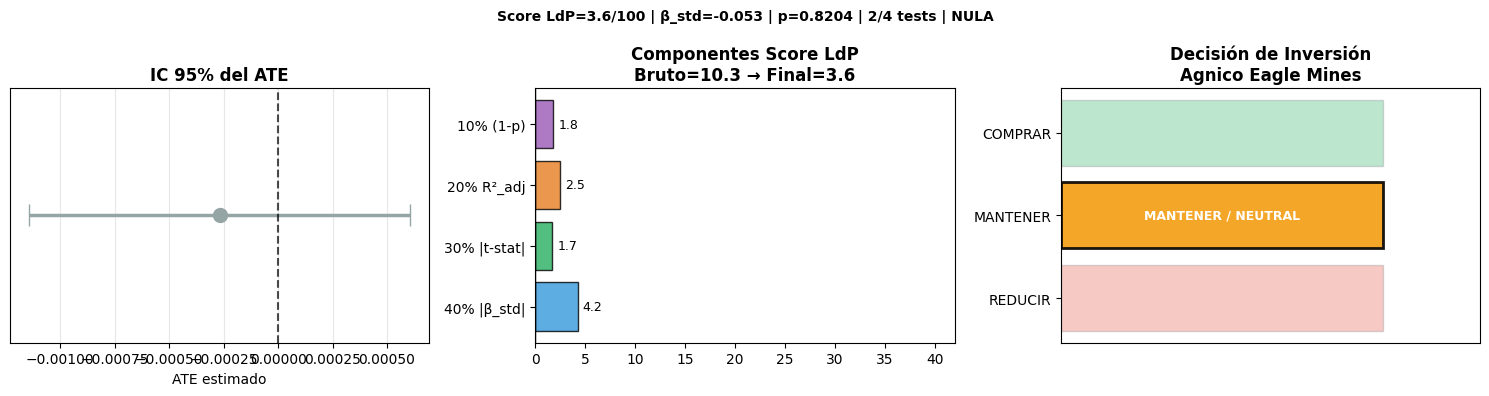

In [ ]:
# CELDA 9 — SCORE CAUSAL LdP + DECISIÓN (CORREGIDA)
# CORRECCIONES:
#   1) Score LdP: 40%|β_std| + 30%|t-stat| + 20%R²_adj + 10%(1-p)
#      con penalizaciones multiplicativas (no suma simple de componentes)
#   2) alpha_sidak renombrado correctamente (no es BH FDR)
#      → BH FDR simultáneo está en Cell 12
#   3) N_ACTIVOS_PORTAFOLIO = 10 (portafolio commodities)
# ============================================================
import matplotlib.pyplot as plt
import numpy as np

N_ACTIVOS_PORTAFOLIO = 13

# ── Corrección de multiplicidad (POR ACTIVO, no simultáneo)
# NOTA: estas son correcciones individuales
# El BH FDR SIMULTÁNEO sobre todos los activos se aplica en Cell 12
alpha_original = 0.05
alpha_bonferroni = alpha_original / N_ACTIVOS_PORTAFOLIO
alpha_sidak      = 1 - (1 - alpha_original) ** (1 / N_ACTIVOS_PORTAFOLIO)
# ↑ Šidák (FWER), NO BH FDR — corregido el nombre

# ════════════════════════════════════════════════════════════
# SCORE CAUSAL LdP (López de Prado & Zoonekynd 2025)
# Fórmula: 40/30/20/10 sobre variables estandarizadas
# ════════════════════════════════════════════════════════════
BETA_STD_MAX = 0.5    # normalización: |β_std| = 0.5 → score_beta = 1.0
T_STAT_MAX   = 4.0    # normalización: |t| = 4.0 → score_t = 1.0

def score_causal_ldp(beta_std, t_stat, r2_adj, p_value,
                     passes_placebo, passes_dsr, passes_bh=True):
    """
    Score Causal — López de Prado & Zoonekynd (2025)
    Componentes (máx 100 puntos antes de penalizaciones):
      40% → |β_std| normalizado al máximo esperado
      30% → |t-stat| normalizado al máximo esperado
      20% → R²_ajustado
      10% → (1 - p_value)
    Penalizaciones multiplicativas:
      × 0.0 si falla Placebo  (relación no causal — eliminación total)
      × 0.5 si falla DSR      (señal frágil bajo múltiples trials)
      × 0.7 si falla BH FDR   (no sobrevive corrección de multiplicidad)
    """
    # Componentes normalizados [0, 1]
    s_beta = min(abs(beta_std) / BETA_STD_MAX, 1.0)   # 40%
    s_t    = min(abs(t_stat)   / T_STAT_MAX,   1.0)   # 30%
    s_r2   = max(r2_adj,    0.0)                       # 20%
    s_p    = max(1.0 - p_value, 0.0)                   # 10%

    score_raw = (0.40*s_beta + 0.30*s_t + 0.20*s_r2 + 0.10*s_p) * 100

    # Penalizaciones multiplicativas secuenciales
    penalty = 1.0
    if not passes_placebo: penalty *= 0.0   # fatal
    if not passes_dsr:     penalty *= 0.5
    if not passes_bh:      penalty *= 0.7

    return {
        "score_ldp"         : round(score_raw * penalty, 2),
        "score_raw"         : round(score_raw, 2),
        "penalty"           : round(penalty, 3),
        "s_beta_contrib"    : round(0.40*s_beta*100, 2),
        "s_t_contrib"       : round(0.30*s_t*100,   2),
        "s_r2_contrib"      : round(0.20*s_r2*100,  2),
        "s_p_contrib"       : round(0.10*s_p*100,   2),
    }

# BH FDR por activo — provisional (Cell 12 aplica el verdadero simultáneo)
# Aquí usamos Šidák como referencia conservadora individual
bh_ok_provisional = p_value_final < alpha_sidak

score_result = score_causal_ldp(
    beta_std      = beta_std_final,       # ← Cell 7
    t_stat        = t_stat_final,         # ← Cell 7
    r2_adj        = r2_adj_final,         # ← Cell 7
    p_value       = p_value_final,        # ← Cell 7
    passes_placebo= placebo_ok,           # ← Cell 8
    passes_dsr    = dsr_ok,              # ← Cell 8
    passes_bh     = bh_ok_provisional,   # provisional hasta Cell 12
)
score = score_result["score_ldp"]

# ── Decisión de inversión ────────────────────────────────────
ic_positivo = ci_lo_final > 0
ic_negativo = ci_hi_final < 0
sig_bonf    = p_value_final < alpha_bonferroni
sig_sidak   = p_value_final < alpha_sidak
sig_nominal = p_value_final < alpha_original
tests_ok    = tests_pasados >= 3   # ≥3 de 4

if ic_positivo and sig_bonf and tests_ok:
    decision = "COMPRAR / SOBREPONDERAR"; confianza = "ALTA";     color_dec = "#27AE60"
elif ic_positivo and sig_sidak and tests_ok:
    decision = "COMPRAR / SOBREPONDERAR"; confianza = "MODERADA"; color_dec = "#2ECC71"
elif (not ic_negativo) and sig_nominal and ate_final > 0:
    decision = "MANTENER / NEUTRAL";      confianza = "BAJA";     color_dec = "#F39C12"
elif ic_negativo and sig_bonf:
    decision = "REDUCIR / INFRAPONDERAR"; confianza = "ALTA";     color_dec = "#E74C3C"
else:
    decision = "MANTENER / NEUTRAL";      confianza = "NULA" if not sig_nominal else "INDETERMINADA"
    color_dec = "#95A5A6"

print("="*60)
print(f"SCORE CAUSAL LdP — {ASSET_NAME} ({ASSET_TICKER})")
print("="*60)
print(f"\n  Fórmula: 40%|β_std| + 30%|t| + 20%R²_adj + 10%(1-p) × penalizaciones")
print(f"\n  β_std            : {beta_std_final:+.4f}  → contrib: {score_result['s_beta_contrib']:.1f}/40")
print(f"  t-stat           : {t_stat_final:+.4f}  → contrib: {score_result['s_t_contrib']:.1f}/30")
print(f"  R²_adj           : {r2_adj_final:.4f}  → contrib: {score_result['s_r2_contrib']:.1f}/20")
print(f"  p-value          : {p_value_final:.4f}  → contrib: {score_result['s_p_contrib']:.1f}/10")
print(f"\n  Score bruto      : {score_result['score_raw']:.2f}/100")
print(f"  Penalización     : ×{score_result['penalty']:.3f}  "
      f"{'(Placebo ✗ → eliminación total)' if not placebo_ok else '(DSR ✗ → ×0.5)' if not dsr_ok else '(Šidák ✗ → ×0.7)' if not bh_ok_provisional else '(sin penalización)'}")
print(f"\n  ★ SCORE LdP FINAL: {score:.2f}/100")
print(f"\n  alpha Bonferroni : {alpha_bonferroni:.4f}")
print(f"  alpha Šidák      : {alpha_sidak:.4f}  ← FWER individual (no BH FDR)")
print(f"  → BH FDR simultáneo sobre {N_ACTIVOS_PORTAFOLIO} activos: ver Cell 12")
print(f"\n  Tests validación : {tests_pasados}/4")
print(f"  DECISIÓN         : {decision}")
print(f"  CONFIANZA        : {confianza}")
print("="*60)

# Guardar resultado para Cell 12
if '_resultados_portafolio' not in globals():
    _resultados_portafolio = {}
_resultados_portafolio[ASSET_TICKER] = {
    "asset_name"   : ASSET_NAME,
    "ticker"       : ASSET_TICKER,
    "treatment"    : TREATMENT,
    "beta_std"     : beta_std_final,
    "t_stat"       : t_stat_final,
    "r2_adj"       : r2_adj_final,
    "p_value"      : p_value_final,
    "ate"          : ate_final,
    "ci_lo"        : ci_lo_final,
    "ci_hi"        : ci_hi_final,
    "dsr"          : dsr_result["dsr"],
    "dsr_ok"       : dsr_ok,
    "placebo_ok"   : placebo_ok,
    "tests_pasados": tests_pasados,
    "score_raw"    : score_result["score_raw"],
    "score_ldp"    : score,
    "decision"     : decision,
}
print(f"\n✓ Resultado guardado en _resultados_portafolio['{ASSET_TICKER}']")
print(f"  Activos procesados hasta ahora: {list(_resultados_portafolio.keys())}")

# Gráfico
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax1 = axes[0]
ax1.errorbar(x=[ate_final], y=[0],
             xerr=[[ate_final-ci_lo_final],[ci_hi_final-ate_final]],
             fmt='o', color=color_dec, markersize=10, capsize=8, linewidth=2.5)
ax1.axvline(0, color='black', lw=1.5, ls='--', alpha=0.7)
ax1.set_yticks([]); ax1.set_xlabel("ATE estimado")
ax1.set_title("IC 95% del ATE", fontweight='bold')
ax1.grid(axis='x', alpha=0.3)

ax2 = axes[1]
components = [score_result['s_beta_contrib'], score_result['s_t_contrib'],
              score_result['s_r2_contrib'],   score_result['s_p_contrib']]
labels  = ['40% |β_std|','30% |t-stat|','20% R²_adj','10% (1-p)']
colors  = ['#3498DB','#27AE60','#E67E22','#9B59B6']
ax2.barh(labels, components, color=colors, edgecolor='black', alpha=0.8)
ax2.axvline(0, color='black', lw=1)
ax2.set_xlim(0, 42)
ax2.set_title(f"Componentes Score LdP\nBruto={score_result['score_raw']:.1f} → Final={score:.1f}",
              fontweight='bold')
for i, v in enumerate(components):
    ax2.text(v+0.5, i, f"{v:.1f}", va='center', fontsize=9)

ax3 = axes[2]
niveles   = ["REDUCIR","MANTENER","COMPRAR"]
colores_s = ["#E74C3C","#F39C12","#27AE60"]
bars      = ax3.barh(niveles, [1,1,1], color=colores_s, alpha=0.3, edgecolor='gray')
idx_dec   = 2 if "COMPRAR" in decision else (0 if "REDUCIR" in decision else 1)
bars[idx_dec].set_alpha(0.9); bars[idx_dec].set_edgecolor('black')
bars[idx_dec].set_linewidth(2)
ax3.set_xlim(0, 1.3); ax3.set_xticks([])
ax3.text(0.5, idx_dec, decision, va='center', ha='center',
         fontsize=9, fontweight='bold', color='white')
ax3.set_title(f"Decisión de Inversión\n{ASSET_NAME}", fontweight='bold')

plt.suptitle(
    f"Score LdP={score:.1f}/100 | β_std={beta_std_final:+.3f} | "
    f"p={p_value_final:.4f} | {tests_pasados}/4 tests | {confianza}",
    fontsize=10, fontweight='bold'
)
plt.tight_layout(); plt.show()

CATE — Agnico Eagle Mines (AEM)
  Moderador: VIX  n=49

Subgrupos por VIX (mediana=16.24):
  VIX ALTO                       n=25   ATE=-0.0004  p=0.8147
  VIX BAJO                       n=24   ATE=0.0005  p=0.8132

  n=49 < 50: CausalForestDML requiere más datos.

  ⚠ Heterogeneidad DETECTADA:
     VIX ALTO : ATE=-0.0004
     VIX BAJO : ATE=0.0005
     Diferencia       : 0.0009 (> 30% × |ATE global| = 0.0001)

  → Implicación PPO: α*(t) debe condicionar en VIX_t
     α grande cuando VIX alto  (efecto mayor)
     α pequeño cuando VIX bajo (efecto menor)


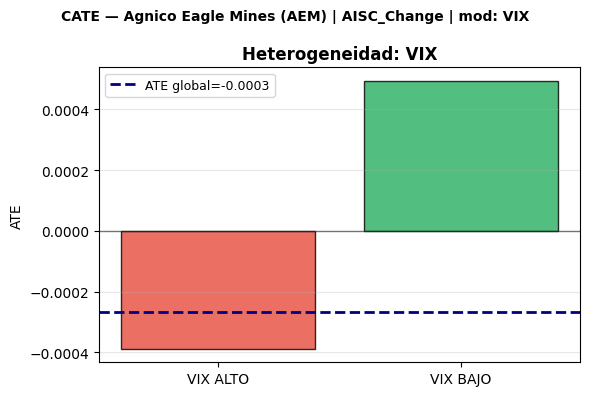

In [ ]:
# ═══════════════════════════════════════════════════════════════════════
# CELDA 10 — HETEROGENEIDAD DEL TRATAMIENTO (CATE)
# Corrección: df_model en lugar de df_clean en ate_sg y CausalForestDML
# ═══════════════════════════════════════════════════════════════════════

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print(f"CATE — {ASSET_NAME} ({ASSET_TICKER})")
print("="*60)

N_MIN_CATE = 50
n = len(df_model)   # ← df_model limpio

# ── Selección del moderador ─────────────────────────────────────────────
MODERADOR = next(
    (c for c in ["VIX", "YIELD_10Y", "MARKET_RETURN", "SP500_Return"]
     if c in df_model.columns),
    None
)

if MODERADOR is None:
    print("  Sin variable de moderación disponible.")
else:
    print(f"  Moderador: {MODERADOR}  n={n}")

    # ── Subgrupos por mediana del moderador ─────────────────────────────
    med_z = np.median(df_model[MODERADOR])
    alto  = df_model[MODERADOR] >= med_z
    bajo  = df_model[MODERADOR] <  med_z

    # ── Función ATE por subgrupo ────────────────────────────────────────
    def ate_sg(mask, nombre):
        # Usar df_model (limpio, sin NaN/Inf)
        df_sub = df_model[mask].copy()
        df_sub.replace([np.inf, -np.inf], np.nan, inplace=True)
        df_sub = df_sub.dropna(
            subset=[TREATMENT, "Future_Return"] + confounders_disponibles)

        if len(df_sub) < 5:
            print(f"  {nombre:<30} n<5 — insuficiente")
            return np.nan, np.nan

        X_ = sm.add_constant(
            df_sub[[TREATMENT] + confounders_disponibles])
        r  = sm.OLS(df_sub["Future_Return"], X_).fit(cov_type='HC3')
        a  = r.params[TREATMENT]
        p  = r.pvalues[TREATMENT]
        print(f"  {nombre:<30} n={len(df_sub):<3}  "
              f"ATE={a:.4f}  p={p:.4f}")
        return a, p

    print(f"\nSubgrupos por {MODERADOR} (mediana={med_z:.2f}):")
    ate_alto, _ = ate_sg(alto, f"{MODERADOR} ALTO")
    ate_bajo, _ = ate_sg(bajo, f"{MODERADOR} BAJO")

    # ── CausalForestDML (si n >= 50) ────────────────────────────────────
    cate_est = None
    if n >= N_MIN_CATE:
        try:
            from econml.dml import CausalForestDML
            from sklearn.ensemble import GradientBoostingRegressor

            Z  = df_model[[MODERADOR]].values
            W_ = df_model[confounders_disponibles].values
            T_ = df_model[TREATMENT].values
            Y_ = df_model["Future_Return"].values

            cf = CausalForestDML(
                model_y       = GradientBoostingRegressor(
                                    n_estimators=100, random_state=42),
                model_t       = GradientBoostingRegressor(
                                    n_estimators=100, random_state=42),
                n_estimators  = 200,
                cv            = 5,
                random_state  = 42
            )
            cf.fit(Y_, T_, X=Z, W=W_)
            cate_est = cf.effect(Z)
            print(f"\n  CausalForestDML: "
                  f"media={np.mean(cate_est):.4f}  "
                  f"std={np.std(cate_est):.4f}")
        except Exception as e:
            print(f"\n  CausalForestDML error: {e}")
    else:
        print(f"\n  n={n} < {N_MIN_CATE}: CausalForestDML requiere más datos.")

    # ── Heterogeneidad significativa ────────────────────────────────────
    if not np.isnan(ate_alto) and not np.isnan(ate_bajo):
        diff = abs(ate_alto - ate_bajo)
        umbral_het = abs(ate_final) * 0.30
        if diff > umbral_het:
            print(f"\n  ⚠ Heterogeneidad DETECTADA:")
            print(f"     {MODERADOR} ALTO : ATE={ate_alto:.4f}")
            print(f"     {MODERADOR} BAJO : ATE={ate_bajo:.4f}")
            print(f"     Diferencia       : {diff:.4f} "
                  f"(> 30% × |ATE global| = {umbral_het:.4f})")
            print(f"\n  → Implicación PPO: α*(t) debe condicionar en {MODERADOR}_t")
            print(f"     α grande cuando {MODERADOR} alto  (efecto mayor)")
            print(f"     α pequeño cuando {MODERADOR} bajo (efecto menor)")
        else:
            print(f"\n  Heterogeneidad baja (diff={diff:.4f} < {umbral_het:.4f})")

    # ── Visualización ───────────────────────────────────────────────────
    n_plots = 1 if cate_est is None else 2
    fig, axes = plt.subplots(1, n_plots,
                             figsize=(6*n_plots, 4))
    if n_plots == 1:
        axes = [axes]

    # Panel 1: ATE por subgrupo
    ax = axes[0]
    grupos  = [f"{MODERADOR} ALTO", f"{MODERADOR} BAJO"]
    valores = [ate_alto if not np.isnan(ate_alto) else 0,
               ate_bajo if not np.isnan(ate_bajo) else 0]
    cols    = ["#E74C3C" if v < 0 else "#27AE60" for v in valores]
    ax.bar(grupos, valores, color=cols, edgecolor='black', alpha=0.8)
    ax.axhline(ate_final, ls='--', color='navy', lw=2,
               label=f'ATE global={ate_final:.4f}')
    ax.axhline(0, ls='-',  color='black', lw=1, alpha=0.5)
    ax.set_ylabel("ATE")
    ax.legend(fontsize=9)
    ax.grid(axis='y', alpha=0.3)
    ax.set_title(f"Heterogeneidad: {MODERADOR}", fontweight='bold')

    # Panel 2: CausalForestDML (si disponible)
    if cate_est is not None:
        ax2 = axes[1]
        ax2.hist(cate_est, bins=20, color='steelblue',
                 edgecolor='black', alpha=0.8)
        ax2.axvline(np.mean(cate_est), ls='--', color='red',
                    lw=2, label=f'media={np.mean(cate_est):.4f}')
        ax2.axvline(0, ls='-', color='black', lw=1.5, alpha=0.6)
        ax2.set_xlabel("CATE")
        ax2.set_title("CausalForestDML", fontweight='bold')
        ax2.legend(fontsize=9)

    fig.suptitle(
        f"CATE — {ASSET_NAME} ({ASSET_TICKER}) | "
        f"{TREATMENT} | mod: {MODERADOR}",
        fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()

PASO 6 — BH FDR SIMULTÁNEO + RANKING FINAL

BH FDR α=0.1 | N=1 activos
───────────────────────────────────────────────────────
Ticker      p_raw   p_adj_BH     BH  Score_raw   Score_BH
───────────────────────────────────────────────────────
  AEM        0.8204     0.8204      ✗      10.26       3.59

RANKING FINAL — Score LdP con BH FDR (α=0.1)
   1. ○ AEM      Score=  3.59  β_std=-0.053  t=-0.23  DSR=✗  → MANTENER / NEUTRAL


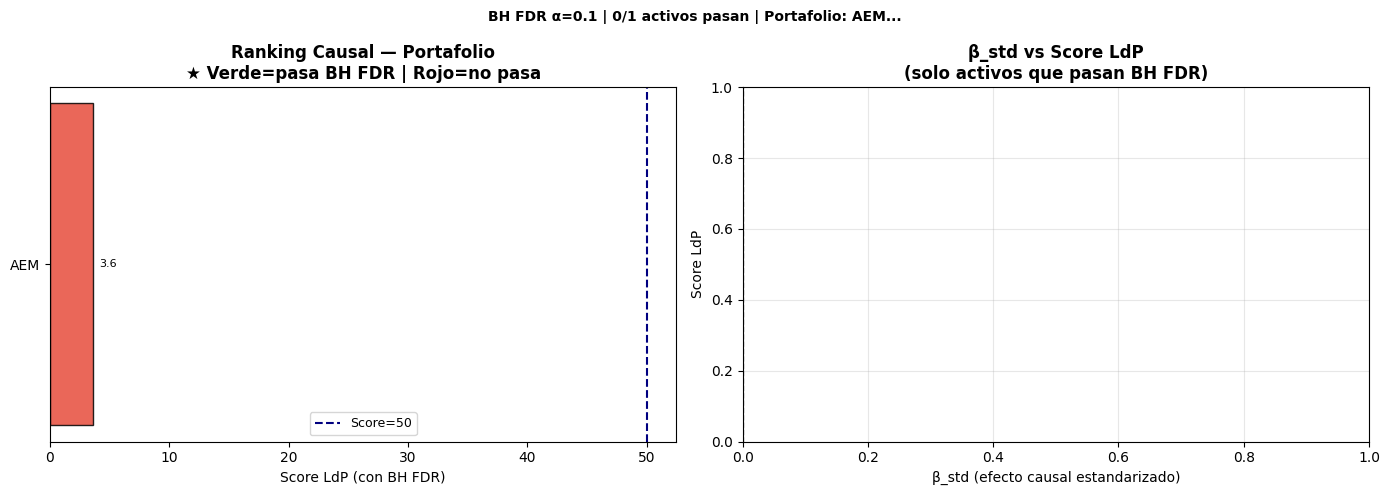


✓ output_m12 disponible: df_rank con score_ldp_bh y bh_ok por activo


In [ ]:
# CELDA 12 — BH FDR SIMULTÁNEO + RANKING FINAL (NUEVA)
# Aplicar DESPUÉS de haber corrido Cells 1-11 para cada activo.
# Cómo usar:
#   1) Corre Cells 1-11 para el 1er activo → guarda en _resultados_portafolio
#   2) Cambia ASSET_TICKER en Cell 2, vuelve a correr Cells 2-11
#   3) Repite para todos los activos
#   4) Corre esta Cell 12 al final — aplica BH FDR y genera ranking
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("="*60)
print("PASO 6 — BH FDR SIMULTÁNEO + RANKING FINAL")
print("="*60)

if '_resultados_portafolio' not in globals() or len(_resultados_portafolio) == 0:
    raise ValueError("❌ No hay resultados en _resultados_portafolio.\n"
                     "   Corre Cells 1-11 para al menos un activo primero.")

# ════════════════════════════════════════════════════════════
# BH FDR (Benjamini-Hochberg 1995)
# Controla la tasa de falsos descubrimientos simultáneamente
# sobre TODOS los activos del portafolio.
# Procedimiento step-up: k* = max{i: p_(i) ≤ i/N × α}
# ════════════════════════════════════════════════════════════
def benjamini_hochberg(p_dict, alpha=0.10):
    """
    Benjamini-Hochberg FDR correction (1995).
    p_dict: {ticker: p_value}
    Retorna: {ticker: {'p_adj': ..., 'reject_h0': ...}}
    """
    tickers = list(p_dict.keys())
    pvals   = np.array([p_dict[t] for t in tickers])
    N       = len(pvals)
    if N == 0:
        return {}

    # Ordenar de menor a mayor
    order   = np.argsort(pvals)
    pvals_s = pvals[order]

    # Umbral BH: p_(i) ≤ i/N × alpha
    thresholds = np.arange(1, N+1) / N * alpha
    below      = pvals_s <= thresholds
    reject     = np.zeros(N, dtype=bool)
    if below.any():
        k_star = int(np.where(below)[0].max())
        reject[:k_star+1] = True

    # p-valores ajustados BH (Benjamini-Yekutieli step-up)
    p_adj_s = np.minimum.accumulate(
        pvals_s[::-1] * N / np.arange(N, 0, -1)
    )[::-1]
    p_adj_s = np.minimum(p_adj_s, 1.0)

    # Restaurar orden original
    p_adj_original  = np.empty(N)
    reject_original = np.empty(N, dtype=bool)
    for new_pos, orig_pos in enumerate(order):
        p_adj_original[orig_pos]  = p_adj_s[new_pos]
        reject_original[orig_pos] = reject[new_pos]

    return {t: {"p_adj": round(float(p_adj_original[i]),6),
                "reject_h0": bool(reject_original[i])}
            for i, t in enumerate(tickers)}

# ── Aplicar BH FDR ───────────────────────────────────────────
ALPHA_FDR = 0.10
p_values  = {t: r["p_value"] for t, r in _resultados_portafolio.items()}
bh_results= benjamini_hochberg(p_values, alpha=ALPHA_FDR)

print(f"\nBH FDR α={ALPHA_FDR} | N={len(p_values)} activos")
print(f"{'─'*55}")
print(f"{'Ticker':<8} {'p_raw':>8} {'p_adj_BH':>10} {'BH':>6} {'Score_raw':>10} {'Score_BH':>10}")
print(f"{'─'*55}")

# Actualizar scores con penalización BH
for ticker, res in _resultados_portafolio.items():
    bh_ok = bh_results[ticker]["reject_h0"]
    p_adj = bh_results[ticker]["p_adj"]
    res["bh_ok"]   = bh_ok
    res["p_adj_bh"]= p_adj
    # Recalcular score con penalización BH actualizada
    score_actualizado = res["score_raw"]
    if not res["placebo_ok"]: score_actualizado *= 0.0
    if not res["dsr_ok"]:     score_actualizado *= 0.5
    if not bh_ok:             score_actualizado *= 0.7
    res["score_ldp_bh"] = round(score_actualizado, 2)

    print(f"  {ticker:<8} {res['p_value']:>8.4f} {p_adj:>10.4f} "
          f"{'✓' if bh_ok else '✗':>6} {res['score_raw']:>10.2f} {res['score_ldp_bh']:>10.2f}")

# ── Ranking final ─────────────────────────────────────────────
df_rank = pd.DataFrame(_resultados_portafolio).T
df_rank["score_ldp_bh"] = df_rank["score_ldp_bh"].astype(float)
df_rank = df_rank.sort_values("score_ldp_bh", ascending=False)

print(f"\n{'='*60}")
print(f"RANKING FINAL — Score LdP con BH FDR (α={ALPHA_FDR})")
print(f"{'='*60}")
for i, (ticker, row) in enumerate(df_rank.iterrows(), 1):
    marker = "★" if row["bh_ok"] else "○"
    print(f"  {i:2}. {marker} {ticker:<8} Score={row['score_ldp_bh']:6.2f}  "
          f"β_std={float(row['beta_std']):+.3f}  "
          f"t={float(row['t_stat']):+.2f}  "
          f"DSR={'✓' if row['dsr_ok'] else '✗'}  "
          f"→ {row['decision']}")

# ── Visualización ranking ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax1 = axes[0]
colors_bar = ['#27AE60' if row["bh_ok"] else '#E74C3C'
              for _, row in df_rank.iterrows()]
bars = ax1.barh(df_rank.index, df_rank["score_ldp_bh"].astype(float),
                color=colors_bar, edgecolor='black', alpha=0.85)
ax1.axvline(50, ls='--', color='navy', lw=1.5, label='Score=50')
ax1.set_xlabel("Score LdP (con BH FDR)")
ax1.set_title("Ranking Causal — Portafolio\n★ Verde=pasa BH FDR | Rojo=no pasa",
              fontweight='bold')
ax1.legend(fontsize=9)
for bar, val in zip(bars, df_rank["score_ldp_bh"].astype(float)):
    ax1.text(val+0.5, bar.get_y()+bar.get_height()/2,
             f"{val:.1f}", va='center', fontsize=8)

ax2 = axes[1]
df_sig = df_rank[df_rank["bh_ok"].astype(bool)]
if len(df_sig) > 0:
    scatter = ax2.scatter(
        df_sig["beta_std"].astype(float),
        df_sig["score_ldp_bh"].astype(float),
        c=df_sig["dsr"].astype(float), cmap='RdYlGn',
        s=200, edgecolors='black', zorder=5, vmin=0.5, vmax=1.0
    )
    plt.colorbar(scatter, ax=ax2, label='DSR')
    for ticker, row in df_sig.iterrows():
        ax2.annotate(ticker, (float(row["beta_std"]), float(row["score_ldp_bh"])),
                     fontsize=8, xytext=(5,3), textcoords='offset points')
ax2.axvline(0, ls='--', color='gray', lw=1)
ax2.set_xlabel("β_std (efecto causal estandarizado)")
ax2.set_ylabel("Score LdP")
ax2.set_title("β_std vs Score LdP\n(solo activos que pasan BH FDR)", fontweight='bold')
ax2.grid(alpha=0.3)

plt.suptitle(
    f"BH FDR α={ALPHA_FDR} | {len(df_sig)}/{len(df_rank)} activos pasan | "
    f"Portafolio: {', '.join(df_rank.index[:3].tolist())}...",
    fontsize=10, fontweight='bold'
)
plt.tight_layout()
plt.show()

print(f"\n✓ output_m12 disponible: df_rank con score_ldp_bh y bh_ok por activo")
output_m12 = df_rank.copy()

In [ ]:
# CELDA 11 — EXPORTACIÓN ACUMULATIVA (ACTUALIZADA)
# Agrega los campos nuevos: beta_std, t_stat, r2_adj, dsr_ok, dsr_value
# ============================================================
import pickle
import os
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

RUTA_M11 = '/content/drive/MyDrive/modulo_1_1_resultados.pkl'

# ── 1) Cargar o crear registro ────────────────────────────────────────────────
if os.path.exists(RUTA_M11):
    with open(RUTA_M11, 'rb') as f:
        registro = pickle.load(f)
    ya_existentes = list(registro['senales_causales'].keys())
    print(f"Archivo existente. Activos registrados: {ya_existentes}")
else:
    registro = {'senales_causales': {}}
    ya_existentes = []
    print("Archivo nuevo — primer activo del portafolio causal.")

# ── 2) Señal del activo actual (campos completos) ─────────────────────────────
senal_nueva = {
    # ── Estimación OLS-HAC original (ATE bruto)
    'ate':          ate_final,
    'p_value':      p_value_final,
    'ci_lo':        ci_lo_final,
    'ci_hi':        ci_hi_final,
    'metodo':       metodo_final,
    'ate_ols':      ate_ols_ref,

    # ── NUEVOS: β_std y estadísticas del modelo estandarizado (HC3)
    'beta_std':     beta_std_final,      # ← para Score LdP y ranking cross-activo
    't_stat':       t_stat_final,        # ← para Score LdP
    'r2_adj':       r2_adj_final,        # ← para Score LdP

    # ── Score y decisión (versión notebook original, para referencia)
    'score':        score,
    'decision':     decision,
    'confianza':    confianza,

    # ── Tests de refutación
    'placebo_ok':   placebo_ok,
    'rcc_ok':       rcc_ok,
    'subset_ok':    subset_ok,
    'dsr_ok':       dsr_ok,              # ← NUEVO
    'dsr_value':    dsr_result['dsr'],   # ← NUEVO: valor numérico
    'dsr_sr_obs':   dsr_result['sr_observed'],  # ← NUEVO
    'ovb_rv':       rv,

    # ── Configuración del activo
    'asset_type':   ASSET_TYPE,
    'treatment':    TREATMENT,
    'confounders':  confounders_disponibles,
    'colisionadores': COLISIONADORES,
    'lag':          LAG_PERIODS,
    'frequency':    FREQUENCY,
    'n_obs':        len(df_clean),
    'transformaciones': _transformaciones_aplicadas,
    # ── Descubrimiento causal (Paso 2 LiNGAM) ─────────────
    'lingam_result': lingam_result if 'lingam_result' in globals() else None,
    'lingam_ok':     lingam_ok     if 'lingam_ok'     in globals() else False,
}

if ASSET_TICKER in ya_existentes:
    print(f"\nActualizando: {ASSET_TICKER}")
else:
    print(f"\nAgregando: {ASSET_TICKER}")

registro['senales_causales'][ASSET_TICKER] = senal_nueva

with open(RUTA_M11, 'wb') as f:
    pickle.dump(registro, f)
print(f"Guardado en: {RUTA_M11}")

# ── 3) Tabla resumen acumulada ────────────────────────────────────────────────
senales = registro['senales_causales']
df_resumen = pd.DataFrame({
    ticker: {
        'Score (notebook)': s.get('score', ''),
        'β_std':            round(s.get('beta_std', float('nan')), 4),
        't-stat':           round(s.get('t_stat', float('nan')), 3),
        'ATE (HAC)':        round(s.get('ate', float('nan')), 4),
        'p-valor':          round(s.get('p_value', float('nan')), 4),
        'R²_adj':           round(s.get('r2_adj', float('nan')), 4),
        'Método':           s.get('metodo', 'OLS'),
        'Decisión':         s['decision'],
        'Confianza':        s.get('confianza', ''),
        'OVB_RV':           round(s.get('ovb_rv', 0), 3),
        'n_obs':            s.get('n_obs', ''),
        'Placebo':          'V' if s['placebo_ok'] else 'X',
        'RCC':              'V' if s['rcc_ok'] else 'X',
        'Subset':           'V' if s['subset_ok'] else 'X',
        'DSR':              'V' if s.get('dsr_ok', False) else 'X',   # ← NUEVO
        'Tratamiento':      s.get('treatment', ''),
    }
    for ticker, s in senales.items()
}).T.sort_values('Score (notebook)', ascending=False)

df_resumen.index.name = 'Ticker'

print(f"\n{'='*65}")
print(f"PORTAFOLIO CAUSAL — {len(senales)} ACTIVOS ACUMULADOS")
print(f"{'='*65}")
display(df_resumen.style
    .background_gradient(subset=['Score (notebook)'], cmap='RdYlGn', vmin=0, vmax=100)
    .format({'β_std': '{:.4f}', 't-stat': '{:.3f}',
             'ATE (HAC)': '{:.4f}', 'p-valor': '{:.4f}', 'R²_adj': '{:.4f}'})
    .set_caption(f'Portafolio Causal — {len(senales)} activos'))

# ── 4) Progreso ───────────────────────────────────────────────────────────────
OBJETIVO   = 20
pendientes = max(0, OBJETIVO - len(senales))
barra      = 'o' * len(senales) + '.' * pendientes

print(f"\nProgreso: [{barra}] {len(senales)}/{OBJETIVO}")
conteo = Counter(['COMPRAR' if 'COMPRAR' in s['decision'] else
                  'MANTENER' if 'MANTENER' in s['decision'] else 'REDUCIR'
                  for s in senales.values()])
print(f"  COMPRAR  : {conteo.get('COMPRAR', 0)}")
print(f"  MANTENER : {conteo.get('MANTENER', 0)}")
print(f"  REDUCIR  : {conteo.get('REDUCIR', 0)}")

if pendientes > 0:
    print(f"\n  Faltan {pendientes} activos. Cambiar ASSET_TICKER en Celda 2 y ejecutar.")
else:
    print(f"\n  ✅ Universo completo. Ejecutar Celda 12 para BH FDR y Score LdP final.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archivo existente. Activos registrados: ['MSFT', 'NVDA', 'TSLA', 'META', 'CVX', 'BHP', 'GOOGL', 'ALM', 'JPM', 'WPM', 'FCX', 'AAPL']

Agregando: AEM
Guardado en: /content/drive/MyDrive/modulo_1_1_resultados.pkl

PORTAFOLIO CAUSAL — 13 ACTIVOS ACUMULADOS


,Score (notebook),β_std,t-stat,ATE (HAC),p-valor,R²_adj,Método,Decisión,Confianza,OVB_RV,n_obs,Placebo,RCC,Subset,DSR,Tratamiento
Ticker,,,,,,,,,,,,,,,,
GOOGL,40,0.2434,0.611,2.0078,0.5412,0.9939,OLS-HC3 (std) + OLS-HAC (bruto),MANTENER / NEUTRAL,NULA (no significativo),0.000000,7,V,X,V,X,RND_Growth
ALM,34,0.5023,0.189,3.4657,0.8502,-0.1946,OLS-HC3 (std) + OLS-HAC (bruto),MANTENER / NEUTRAL,NULA (no significativo),0.000000,7,X,X,X,X,EBITDA_Growth
JPM,25,-0.0101,-0.007,-0.0000,0.9946,0.9296,OLS-HC3 (std) + OLS-HAC (bruto),MANTENER / NEUTRAL,NULA (no significativo),0.000000,7,V,V,V,X,NIM_Change
TSLA,17.060000,0.2880,2.012,0.8899,0.0442,0.0522,OLS-HC3 (std) + OLS-HAC (bruto),MANTENER / NEUTRAL,BAJA,0.001000,62,V,V,V,X,SectorDemand_Change
AAPL,14.300000,0.2342,1.638,0.3230,0.1013,0.0429,OLS-HC3 (std) + OLS-HAC (bruto),MANTENER / NEUTRAL,NULA,0.000000,82,V,V,V,X,SectorDemand_Change
BHP,14,-0.0106,-0.003,-0.0138,0.9978,-0.0239,OLS-HC3 (std) + OLS-HAC (bruto),MANTENER / NEUTRAL,NULA (no significativo),0.000000,8,X,X,X,X,CAPEX_Growth
WPM,14,0.0214,0.030,0.0261,0.9764,0.9145,OLS-HC3 (std) + OLS-HAC (bruto),MANTENER / NEUTRAL,NULA (no significativo),0.000000,7,X,X,X,X,Revenue_Growth
MSFT,11.800000,0.2022,1.204,0.1913,0.2287,0.0401,OLS-HC3 (std) + OLS-HAC (bruto),MANTENER / NEUTRAL,NULA,0.000000,82,V,V,V,X,SectorDemand_Change
FCX,11.050000,0.1465,1.167,0.2670,0.2433,0.1764,OLS-HC3 (std) + OLS-HAC (bruto),MANTENER / NEUTRAL,NULA,0.000000,82,V,V,V,X,CopperPrice_Change



Progreso: [ooooooooooooo.......] 13/20
  COMPRAR  : 0
  MANTENER : 13
  REDUCIR  : 0

  Faltan 7 activos. Cambiar ASSET_TICKER en Celda 2 y ejecutar.


In [2]:
from google.colab import userdata
TOKEN = userdata.get('GITHUB_TOKEN')
import subprocess
subprocess.run(['git', 'config', '--global', 'user.email', 'lriofrio915@gmail.com'])
subprocess.run(['git', 'config', '--global', 'user.name', 'lriofrio915'])
!git clone https://{TOKEN}@github.com/alejandrojho1999-blip/dep-coberturas.git /content/repo
print("OK")

Cloning into '/content/repo'...
remote: Enumerating objects: 567, done.
remote: Counting objects: 100% (567/567), done.
remote: Compressing objects: 100% (302/302), done.
remote: Total 567 (delta 266), reused 526 (delta 225), pack-reused 0 (from 0)
Receiving objects: 100% (567/567), 291.70 KiB | 5.30 MiB/s, done.
Resolving deltas: 100% (266/266), done.
OK


In [12]:
import glob, os

# Buscar en Drive
notebooks = glob.glob('/content/drive/MyDrive/**/*.ipynb', recursive=True)
print("Notebooks en Drive:")
for nb in notebooks:
    print(" -", nb)

Notebooks en Drive:
